<div style="text-align: left; background-color:#4e4e4e; font-family: Trebuchet MS; color:white; padding: 12px; line-height:1.25;border-radius:1px; margin-bottom: 0em; text-align: center; font-size: 38px;border-style: solid;border-color: dark green;">Breast Cancer classification  based  on  gene  expression profile and Survival analysis based on clinical data</div>

<br> </br>
<div> 


## **Background** <a class="anchor" id="0"></a>
Breast  cancer characterises  as  a  family  of  diseases  which  is  conventionally classified  using clinical and pathological criteria such as histological grade and lymphnode metastasis status (LNstatus). In addition, expression of certain receptor proteins such as estrogen receptor (ER), progesterone receptor (PR) and human epidermal growth factor 2 (HER2) is included in deciding treatment strategies and prognosis.(Clarke et al., 2013). Advancements in translational‘omics’ has  been addressing heterogeneity of breast cancer by genomic, transcriptomic,and proteomic profiling to identify several subgroups.(Curtis et al., 2012)(Kao et al., 2011). These subgroups are associated with different biological level information along with  varying  clinical  outcomes(Asleh  et  al.,  2022)(Van ’T Veer et al., 2002). Therefore, refined  classification  based  on  gene  expression presents advanced influence and potential in improving customised breast cancer treatments. 

    
    
  

<blockquote style="margin-right:auto; margin-left:auto; color:white; background-color:#4e4e4e; padding: 1em; margin:24px;">

<font color="white" size=+1.0><b>Objectives</b></font>  
       
<ul>
<li> To identify different sub-types of best cancer patients based on their gene expression.
<li> To extract  statistically  and  biologically  significant,  differentially  expressedgenes between sub-types.
<li> To investigate biological level information of differentially expressed key genes in the context of breast cancer progression.
<li> To determine whether patients with different breast cancer sub-types will have different survival prognoses in addition to other clinical attributes.      
    
</ul>        
</blockquote>



In [ ]:
#Loading required libraries
library(plyr)
library(dplyr)
library(tidyverse)
library(limma)
library(cluster)
library(RColorBrewer)
library(survival)
library(ggplot2)
library(gridExtra)
library(ggfortify)
library(gplots)


### **Data Import** 



In [ ]:
METABRIC <- read.csv('breast_cancer_dash/data/breast-cancer-gene-expression-profiles-metabric/METABRIC_RNA_Mutation.csv')

In [ ]:
str(METABRIC)

### **Dataset**

The Molecular Taxonomy of Breast Cancer International Consortium (METABRIC) database is a Canada-UK Project which contains targeted sequencing data of 1,980 primary breast cancer samples. The dataset was collected by Professor Carlos Caldas from Cambridge Research Institute and Professor Sam Aparicio from the British Columbia Cancer Centre in Canada and published on Nature Communications (Pereira et al., 2016). 
*     This file includes 31 clinical attributes, m-RNA levels z-score for 331 genes, and mutation in 175 genes for 1904 breast cancer patients

#### Clinical attributes in the dataset:

| Name                           | Type   | Description |
|--------------------------------|--------|-------------|
| patient_id                     | object | Patient ID  |
| age_at_diagnosis               | float  |    Age of the patient at diagnosis time         |
| type_of_breast_surgery         | object | Breast cancer surgery type: 1-  MASTECTOMY, which refers to a surgery to remove all breast tissue from a breast as a way to treat or prevent breast cancer.  2- BREAST CONSERVING, which refers to a urgery where only the part of the breast that has cancer is removed     |
| cancer_type                    | object | Breast cancer types: 1- Breast Cancer or  2- Breast Sarcoma           |
| cancer_type_detailed           | object | Detailed Breast cancer types: 1- Breast Invasive Ductal Carcinoma 2- Breast Mixed Ductal and Lobular Carcinoma 3- Breast Invasive Lobular Carcinoma  4- Breast Invasive Mixed Mucinous Carcinoma 5- Metaplastic Breast Cancer   |
| cellularity                    | object | Cancer cellularity post chemotherapy, which refers to the amount of tumor cells in the specimen and their arrangement into clusters         |
| chemotherapy                   | int    |  Whether or not the patient had chemotherapy as a treatment (yes/no)    |
| pam50_+_claudin-low_subtype    | object |  Pam 50: is a tumor profiling test that helps show whether some estrogen receptor-positive (ER-positive), HER2-negative breast cancers are likely to metastasize (when breast cancer spreads to other organs). The claudin-low breast cancer subtype is defined by gene expression characteristics, most prominently: Low expression of cell–cell adhesion genes, high expression of epithelial–mesenchymal transition (EMT) genes, and stem cell-like/less differentiated gene expression patterns       |
| cohort                         | float  |  Cohort is a group of subjects who share a defining characteristic (It takes a value from 1 to 5)        |
| er_status_measured_by_ihc      | float  |  To assess if estrogen receptors are expressed on cancer cells by using immune-histochemistry (a dye used in pathology that targets specific antigen, if it is there, it will give a color, it is not there, the tissue on the slide will be colored)  (positive/negative)         |
| er_status                      | object |   Cancer cells are positive or negative for estrogen receptors          |
| neoplasm_histologic_grade      | int  |  Determined by pathology by looking the nature of the cells, do they look aggressive or not  (It takes a value from 1 to 3)         |
| her2_status_measured_by_snp6   | object | To assess if the cancer positive for HER2 or not by using advance molecular techniques (Type of next generation sequencing)       |
| her2_status                    | object |   Whether the cancer is positive or negative for HER2          |
| tumor_other_histologic_subtype | object |  Type of the cancer based on microscopic examination of the cancer tissue (It takes a value of  'Ductal/NST', 'Mixed', 'Lobular', 'Tubular/ cribriform', 'Mucinous', 'Medullary', 'Other', 'Metaplastic'  )      |
| hormone_therapy                | int |   Whether or not the patient had hormonal as a treatment (yes/no)           |
| inferred_menopausal_state      | object |  Whether the patient is  is post menopausal or not   (post/pre)        |
| integrative_cluster            | object | Molecular subtype of the cancer based on some gene expression (It takes a value from '4ER+', '3', '9', '7', '4ER-', '5', '8', '10', '1', '2', '6')            |
| primary_tumor_laterality       | object |   Whether it is involving the right breast or the left breast           |
| lymph_nodes_examined_positive  | float  |  To take samples of the lymph node during the surgery and see if there were involved by the cancer            |
| mutation_count                 | float  |  Number of gene that has relevant mutations            |
| nottingham_prognostic_index    | float  |   It is used to determine prognosis following surgery for breast cancer. Its value is calculated using three pathological criteria: the size of the tumour; the number of involved lymph nodes; and the grade of the tumour.          |
| oncotree_code                  | object |  The OncoTree is an open-source ontology that was developed at Memorial Sloan Kettering Cancer Center (MSK) for standardizing cancer type diagnosis from a clinical perspective by assigning each diagnosis a unique OncoTree code.           |
| overall_survival_months        | float  |  Duration from the time of the intervention to death        |
| overall_survival               | object |   Target variable wether the patient is alive of dead.          |
| pr_status                      | object |    Cancer cells are positive or negative for progesterone  receptors          |
| radio_therapy                  | int    | Whether or not the patient had radio as a treatment (yes/no)             |
| 3-gene_classifier_subtype      | object | Three Gene classifier subtype It takes a value from 'ER-/HER2-', 'ER+/HER2- High Prolif', nan, 'ER+/HER2- Low Prolif','HER2+'           |
| tumor_size                     | float  | Tumor size measured by imaging techniques            |
| tumor_stage                    | float  | Stage of the cancer based on the involvement of surrounding structures, lymph nodes and distant spread          |
| death_from_cancer              | int  |  Wether the patient's death was due to cancer or not (yes/no)           |


#### Genetic attributes in the dataset:

The genetics part of the dataset contains m-RNA levels z-score for 331 genes, and mutation for 175 genes. 

#### mRNA Z-Scores 
For mRNA expression data, The calculations of the relative expression of an individual gene and tumor to the gene's expression distribution in a reference population is done. That reference population is all samples in the study . The returned value indicates the number of standard deviations away from the mean of expression in the reference population (Z-score). This measure is useful to determine whether a gene is up- or down-regulated relative to the normal samples or all other tumor samples.

The formula is : 

`z = (expression in tumor sample - mean expression in reference sample) / standard deviation of expression in reference sample`

### **Data pre-processing** 

#### **Create expression data matrtix**

In [9]:
#Select all numeric columns 
METABRIC_RNA <- select_if(METABRIC, is.numeric)

#Remove all the columns up-to brca1 gene expression score while keeping patient ID 

METABRIC_RNA <- dplyr::select(METABRIC_RNA, -(2:14))

#Transpose data frame and setting column names to patient ID
METABRIC_RNA <- setNames(data.frame(t(METABRIC_RNA[,-1])), METABRIC_RNA[,1])

#Create data Matrix
METABRIC_RNA <- data.matrix(METABRIC_RNA)

#### **Create dataframe for Clinical attributes**

In [10]:
METABRIC_Clinical <- dplyr::select(METABRIC, (1:31))

str(METABRIC_Clinical)

'data.frame':	1904 obs. of  31 variables:
 $ patient_id                    : int  0 2 5 6 8 10 14 22 28 35 ...
 $ age_at_diagnosis              : num  75.7 43.2 48.9 47.7 77 ...
 $ type_of_breast_surgery        : chr  "MASTECTOMY" "BREAST CONSERVING" "MASTECTOMY" "MASTECTOMY" ...
 $ cancer_type                   : chr  "Breast Cancer" "Breast Cancer" "Breast Cancer" "Breast Cancer" ...
 $ cancer_type_detailed          : chr  "Breast Invasive Ductal Carcinoma" "Breast Invasive Ductal Carcinoma" "Breast Invasive Ductal Carcinoma" "Breast Mixed Ductal and Lobular Carcinoma" ...
 $ cellularity                   : chr  "" "High" "High" "Moderate" ...
 $ chemotherapy                  : int  0 0 1 1 1 0 1 0 0 0 ...
 $ pam50_._claudin.low_subtype   : chr  "claudin-low" "LumA" "LumB" "LumB" ...
 $ cohort                        : num  1 1 1 1 1 1 1 1 1 1 ...
 $ er_status_measured_by_ihc     : chr  "Positve" "Positve" "Positve" "Positve" ...
 $ er_status                     : chr  "Positive" "Pos

## **Exploratory Data Analysis  and Data Visualization** <a class="anchor" id="1"></a>



### **Numerical clinical attributes** 

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.”
Warning message:
“Removed 45 rows containing non-finite values (`stat_density()`).”
Warning message:
“Removed 20 rows containing non-finite values (`stat_density()`).”


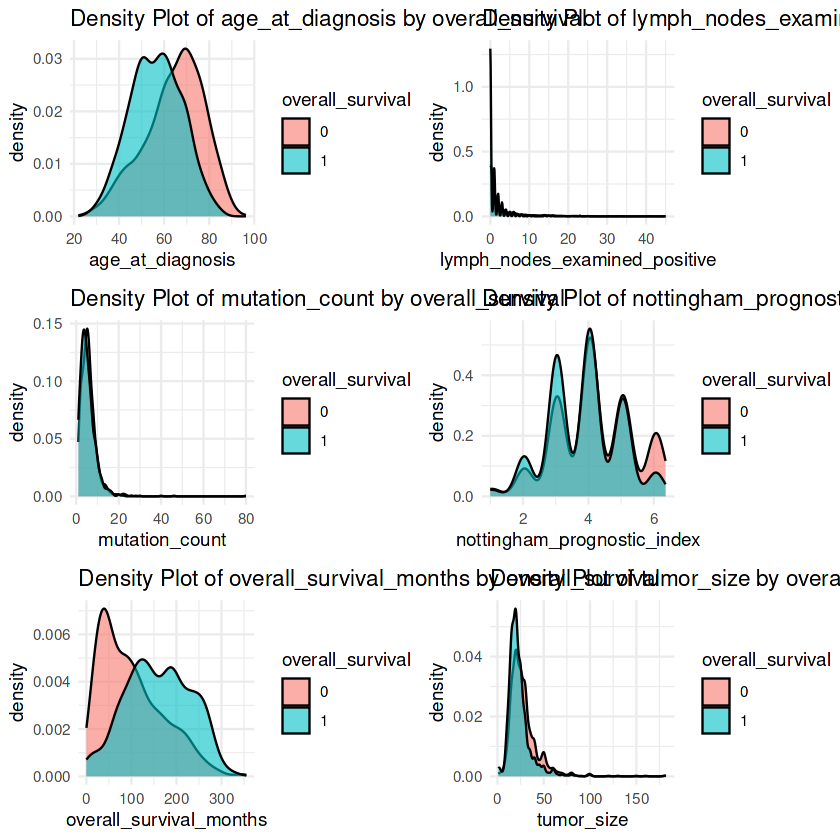

In [11]:
# Convertion of overall survival column to factors
METABRIC_Clinical$overall_survival <- as.factor(METABRIC_Clinical$overall_survival)

# list of numerical clinical attributes
clinical_attributes_to.plot <-c('age_at_diagnosis', 'lymph_nodes_examined_positive','mutation_count','nottingham_prognostic_index', 'overall_survival_months', 'tumor_size')

# Function to create multiple density plots for a list of attributes
create_attribute_density.plots <- function(data, attributes, group_var) {
  plots <- list()
  
  for (attr in attributes) {
    plot <- ggplot(data, aes_string(x = attr, fill = group_var)) +
      geom_density(alpha = 0.6) +
      labs(title = paste("Density Plot of", attr, "by", group_var))+
      theme_minimal()
    
    plots[[attr]] <- plot
  }
  
  return(plots)
}



# Create the plots
plots <- create_attribute_density.plots(METABRIC_Clinical, clinical_attributes_to.plot, "overall_survival")

# Display or save the plots
library(gridExtra)
grid.arrange(grobs = plots, ncol = 2)  # Display plots in a grid layout

Warning message:
“Removed 45 rows containing non-finite values (`stat_boxplot()`).”
Warning message:
“Removed 20 rows containing non-finite values (`stat_boxplot()`).”


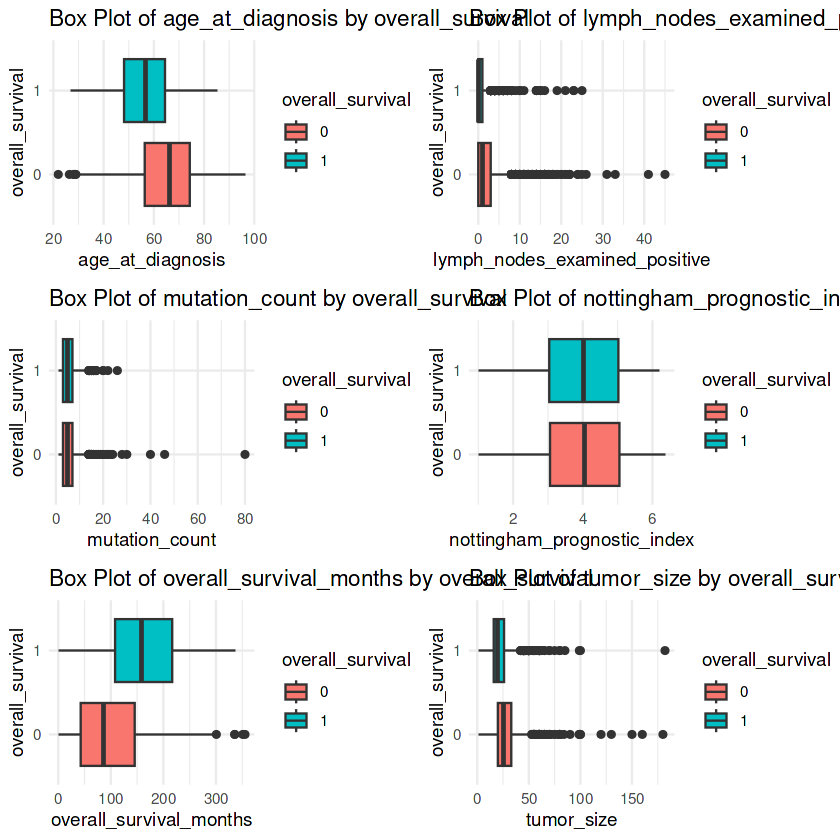

In [12]:
# Function to create multiple grouped box plots for numerical attributes
create_attribute_box.plots <- function(data, numerical_attributes, group_var) {
  plots <- list()
  
  for (attr in numerical_attributes) {
    plot <- ggplot(data, aes_string(x = group_var, y = attr, fill = group_var)) +
      geom_boxplot() +
      labs(title = paste("Box Plot of", attr, "by", group_var),
           x = group_var, y = attr) +
      coord_flip()+
      theme_minimal()
    
    plots[[attr]] <- plot
  }
  
  return(plots)
}

# Create the plots
plots <- create_attribute_box.plots(METABRIC_Clinical, clinical_attributes_to.plot, "overall_survival")

# Display or save the plots
library(gridExtra)
grid.arrange(grobs = plots, ncol = 2)  # Display plots in a grid layout

### **Correlation between numerical attributes**

In [13]:
if (!requireNamespace("ggcorrplot", quietly = TRUE)) {
  install.packages("ggcorrplot")
}
library(ggcorrplot)

[1] "patient_id"                    "age_at_diagnosis"             
 [3] "chemotherapy"                  "cohort"                       
 [5] "neoplasm_histologic_grade"     "hormone_therapy"              
 [7] "lymph_nodes_examined_positive" "mutation_count"               
 [9] "nottingham_prognostic_index"   "overall_survival_months"      
[11] "radio_therapy"                 "tumor_size"                   
[13] "tumor_stage"

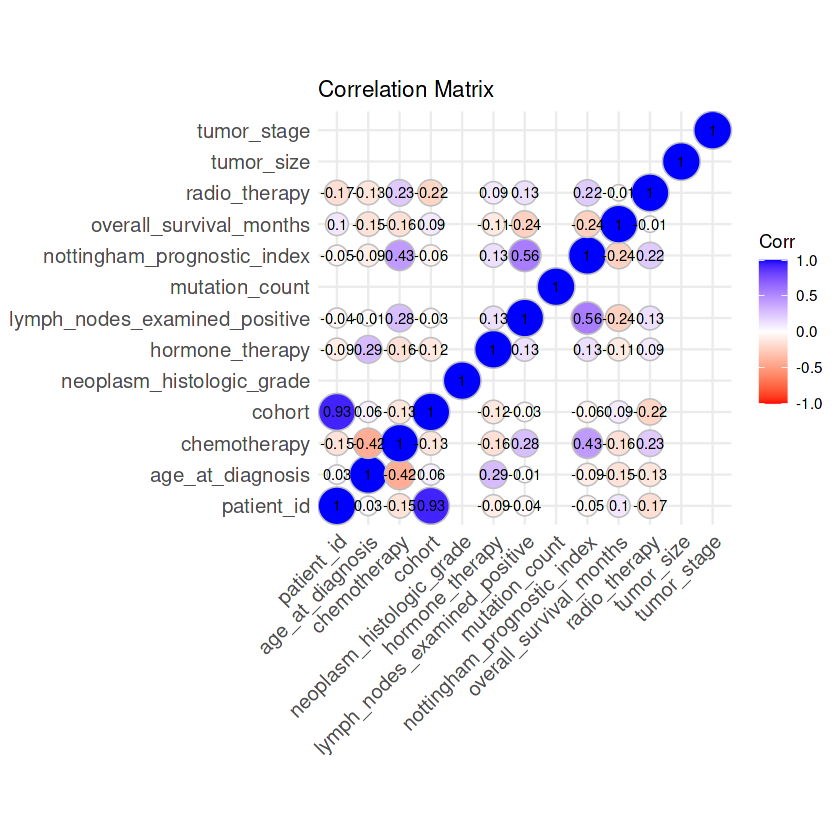

In [15]:
# list of numerical clinical attributes

numerical_clinical_attributes <-names(METABRIC_Clinical)[sapply(METABRIC_Clinical, is.numeric)]
numerical_clinical_attributes

# numerical data
METABRIC_Clinical_numerical <- METABRIC_Clinical %>% select (all_of(numerical_clinical_attributes))
# Calculate the correlation matrix
cor_matrix <- cor(METABRIC_Clinical_numerical) 

# Create the correlation matrix plot
ggcorrplot(cor_matrix, method = "circle", 
           lab = TRUE, lab_size = 3, 
           title = "Correlation Matrix", 
           colors = c("red", "white", "blue"), 
           ggtheme = theme_minimal())

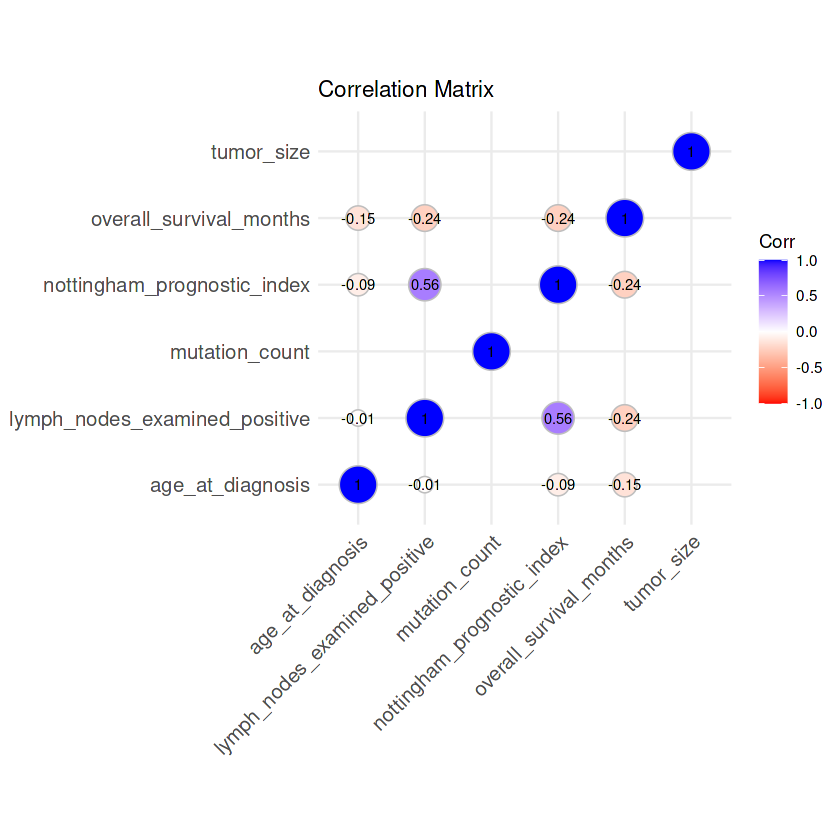

In [16]:
#list of selected numerical attributes

numerical_attributes <- c('age_at_diagnosis', 'lymph_nodes_examined_positive','mutation_count','nottingham_prognostic_index', 'overall_survival_months', 'tumor_size')

# numerical data
METABRIC_Clinical_numerical2 <- METABRIC_Clinical %>% select (all_of(numerical_attributes))
# Calculate the correlation matrix
cor_matrix2 <- cor(METABRIC_Clinical_numerical2) 

# Create the correlation matrix plot
ggcorrplot(cor_matrix2, method = "circle", 
           lab = TRUE, lab_size = 3, 
           title = "Correlation Matrix", 
           colors = c("red", "white", "blue"), 
           ggtheme = theme_minimal())

### **Summary tables**

#### **Age at diagnosis**

In [17]:
summary_table_1 <- METABRIC_Clinical %>%
  summarise(n = length(age_at_diagnosis),
    Mean = mean(age_at_diagnosis, na.rm = TRUE),
    Median = median(age_at_diagnosis, na.rm = TRUE),
    SD = sd(age_at_diagnosis, na.rm = TRUE),
    Min = min(age_at_diagnosis, na.rm = TRUE),
    Max = max(age_at_diagnosis, na.rm = TRUE)) 
  

# Print the summary table
print(summary_table_1)

     n     Mean Median       SD   Min   Max
1 1904 61.08705  61.77 12.97871 21.93 96.29


In [21]:
Table_1 <- ddply(METABRIC_Clinical, "overall_survival", 
                 summarise, 
                 n = length(age_at_diagnosis), 
                 Mean.age_at_diagnosis = mean(age_at_diagnosis), 
                 Stdev.age_at_diagnosis = sd(age_at_diagnosis),
                 Min = min(age_at_diagnosis),
                 Max = max(age_at_diagnosis))
Table_1

overall_survival,n,Mean.age_at_diagnosis,Stdev.age_at_diagnosis,Min,Max
<fct>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
0,1103,64.44475,13.04182,21.93,96.29
1,801,56.46341,11.37746,26.72,85.21


#### **Tumour size**

In [22]:
summary_table_2 <- METABRIC_Clinical %>%
  summarise(n = length(tumor_size),
    Mean = mean(tumor_size, na.rm = TRUE),
    Median = median(tumor_size, na.rm = TRUE),
    SD = sd(tumor_size, na.rm = TRUE),
    Min = min(tumor_size, na.rm = TRUE),
    Max = max(tumor_size, na.rm = TRUE)) 
  

# Print the summary table
print(summary_table_2)

     n     Mean Median       SD Min Max
1 1904 26.23873     23 15.16098   1 182


In [23]:
Table_2 <- ddply(METABRIC_Clinical, "overall_survival", 
                 summarise, 
                 n = length(tumor_size), 
                 Mean.tumor_size = mean(tumor_size, na.rm = TRUE), 
                 Stdev.tumor_size = sd(tumor_size, na.rm = TRUE),
                 Min = min(tumor_size, na.rm = TRUE),
                 Max = max(tumor_size, na.rm = TRUE))
Table_2

overall_survival,n,Mean.tumor_size,Stdev.tumor_size,Min,Max
<fct>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
0,1103,28.36494,16.20109,1,180
1,801,23.31986,13.06156,1,182


### **Categorical clinical attributes** 

In [24]:
# list of categorical clinical attributes

categorical_clinical_attributes <-names(METABRIC_Clinical)[sapply(METABRIC_Clinical, is.character)]
categorical_clinical_attributes

[1] "type_of_breast_surgery"         "cancer_type"                   
 [3] "cancer_type_detailed"           "cellularity"                   
 [5] "pam50_._claudin.low_subtype"    "er_status_measured_by_ihc"     
 [7] "er_status"                      "her2_status_measured_by_snp6"  
 [9] "her2_status"                    "tumor_other_histologic_subtype"
[11] "inferred_menopausal_state"      "integrative_cluster"           
[13] "primary_tumor_laterality"       "oncotree_code"                 
[15] "pr_status"                      "X3.gene_classifier_subtype"    
[17] "death_from_cancer"

#### **Frequency plots for categrical attributes**

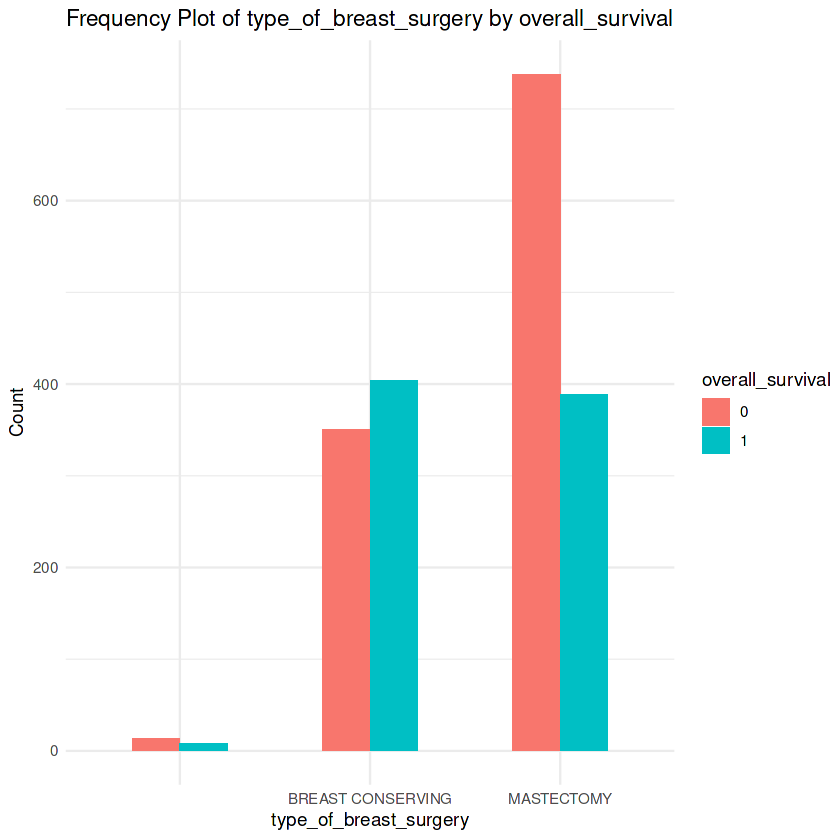

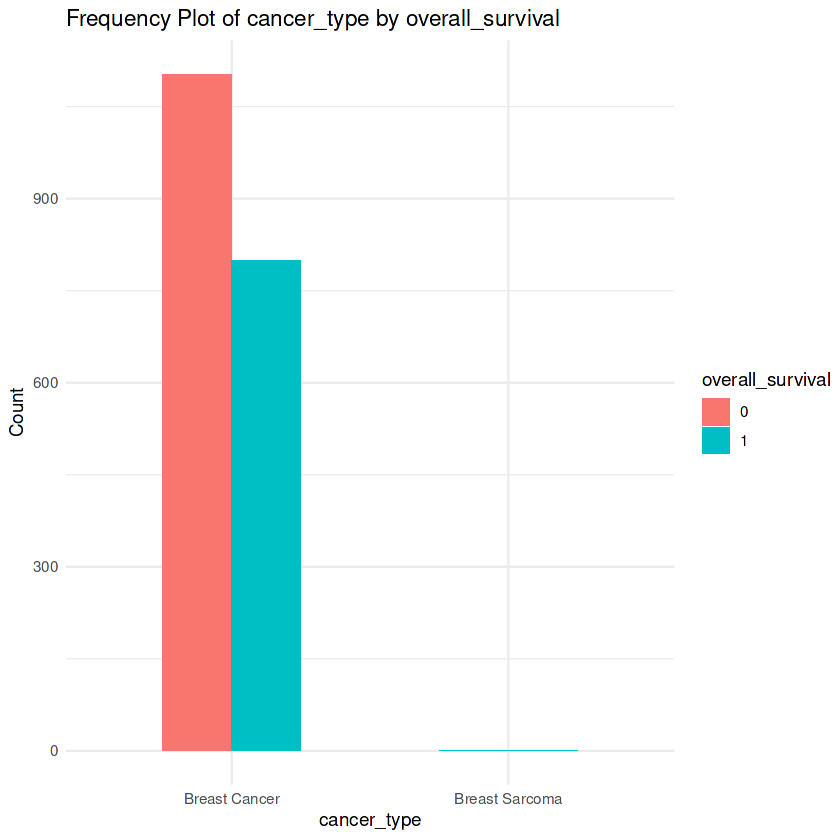

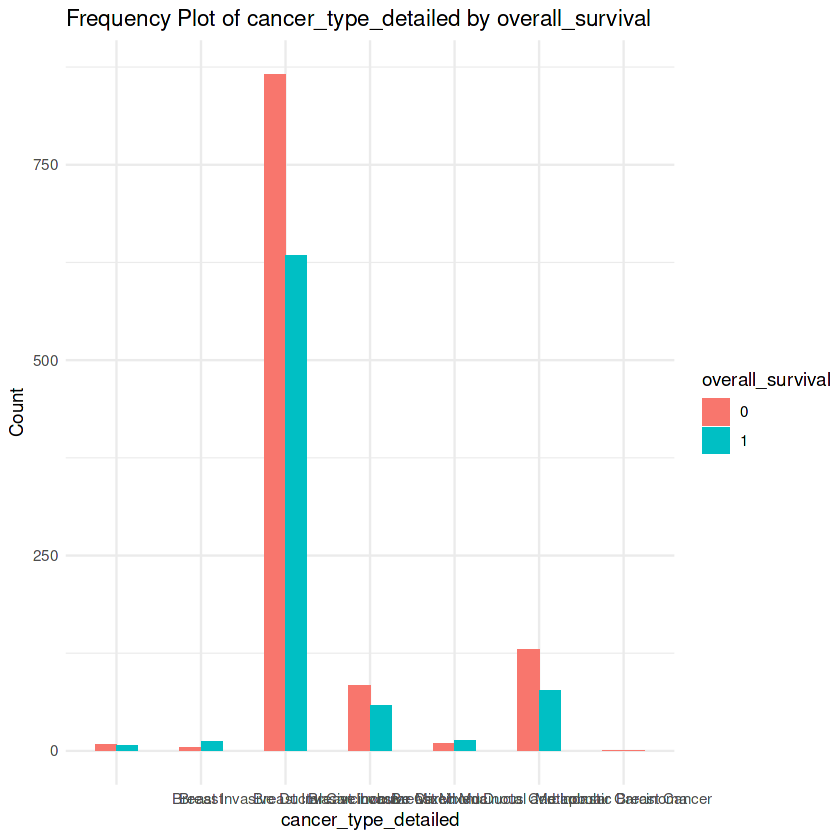

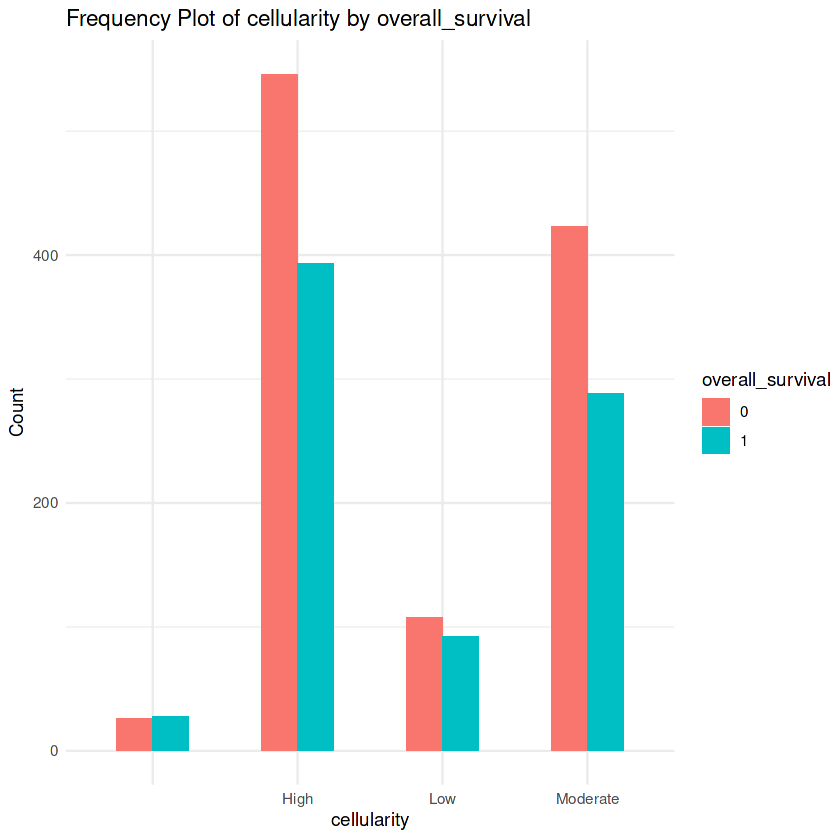

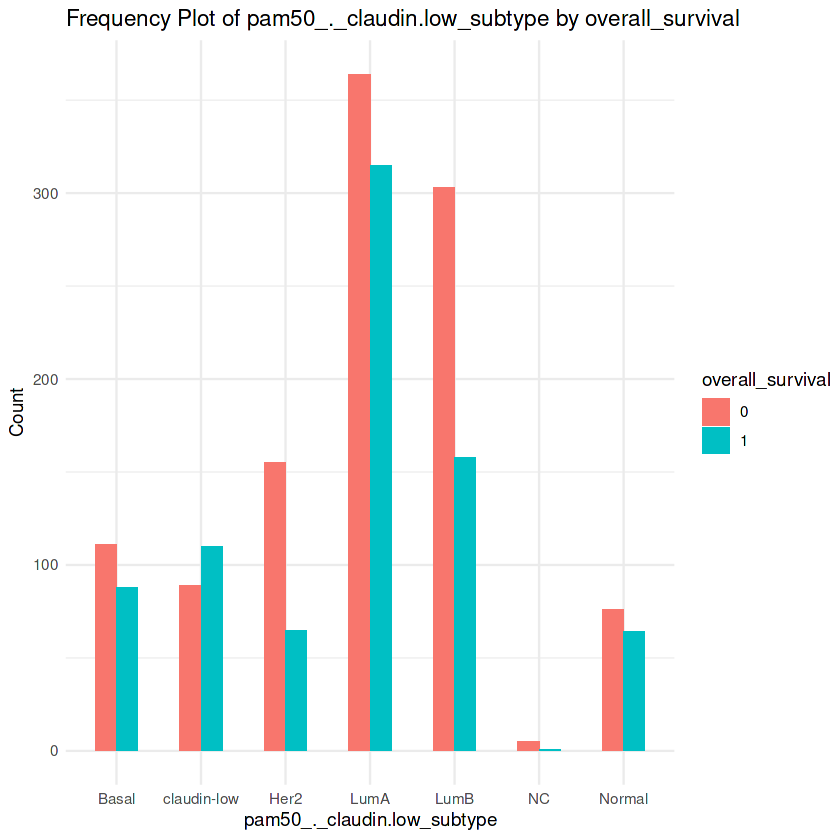

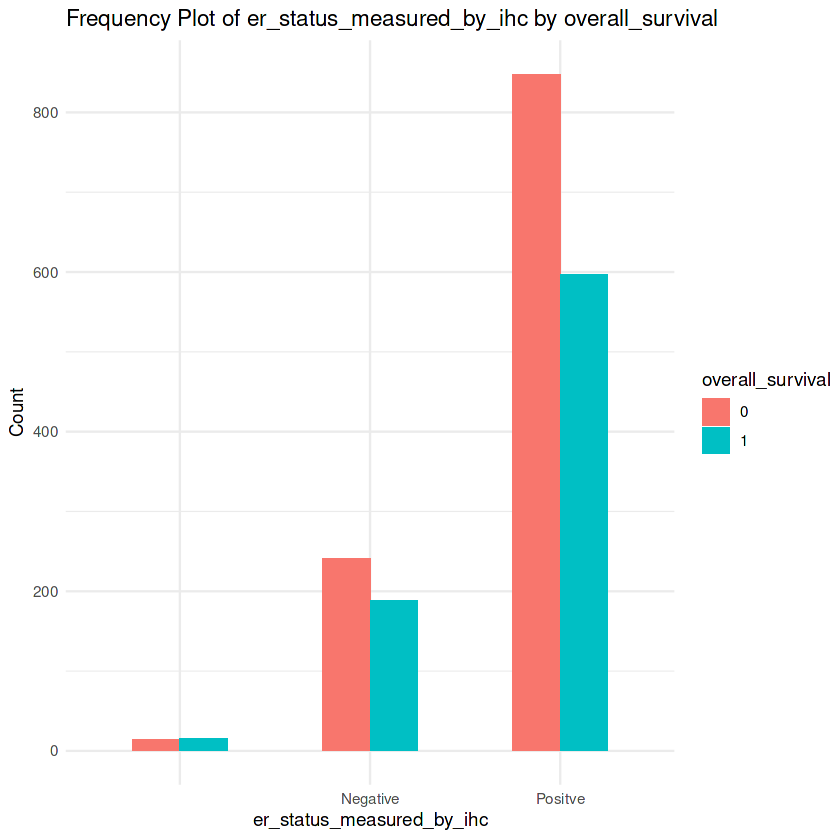

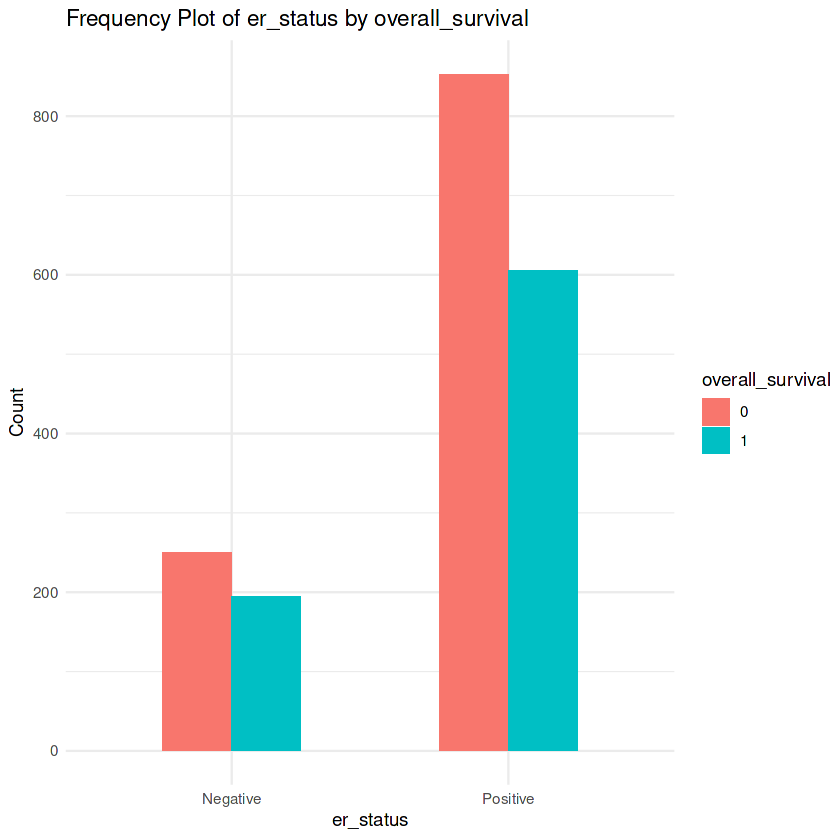

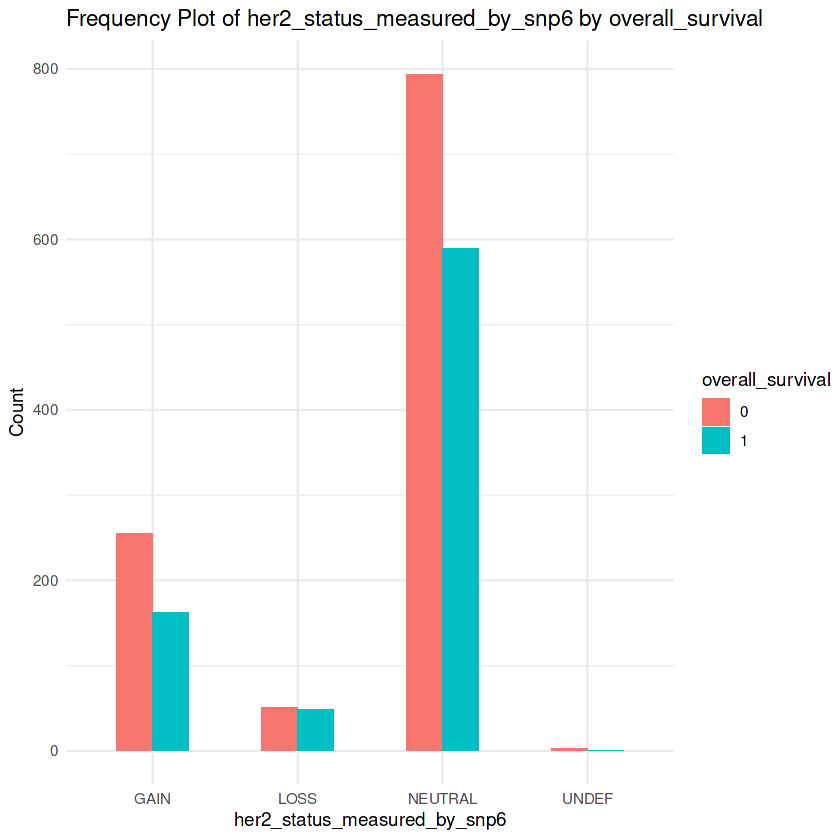

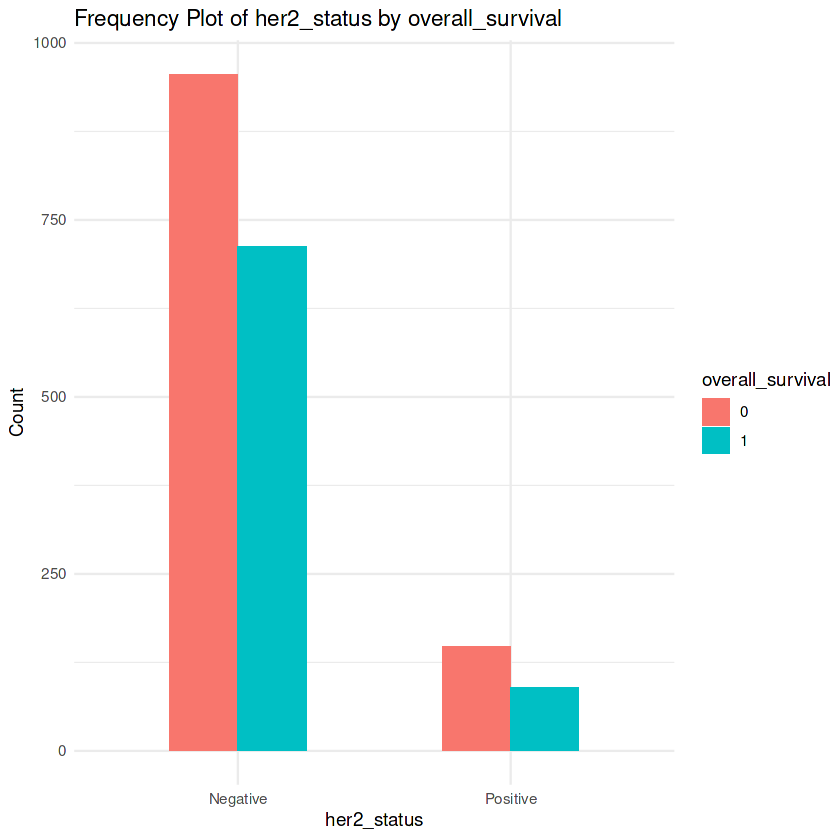

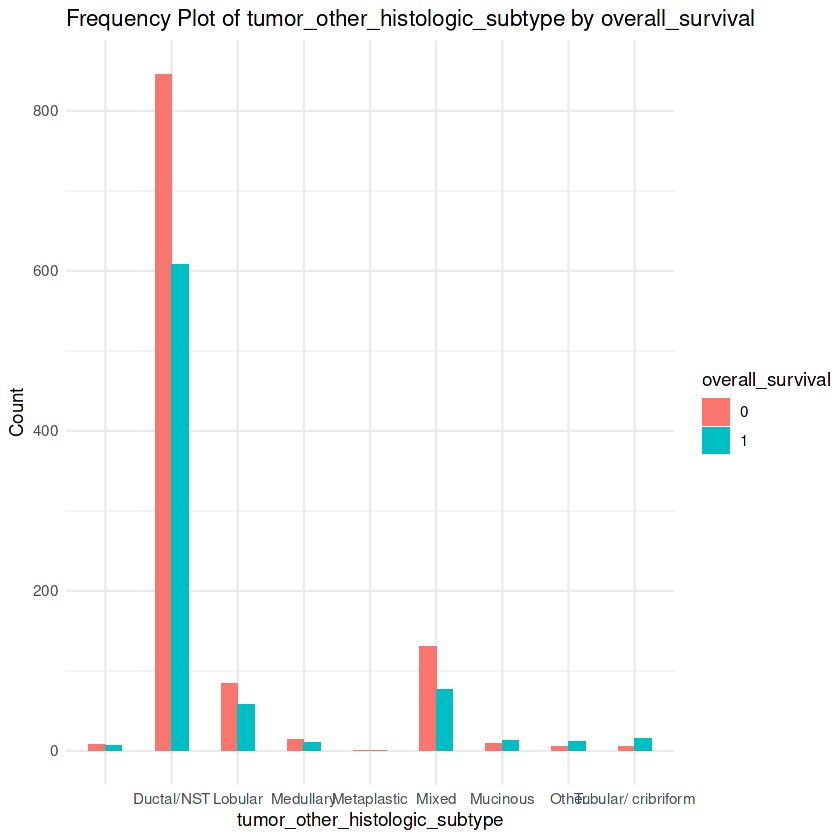

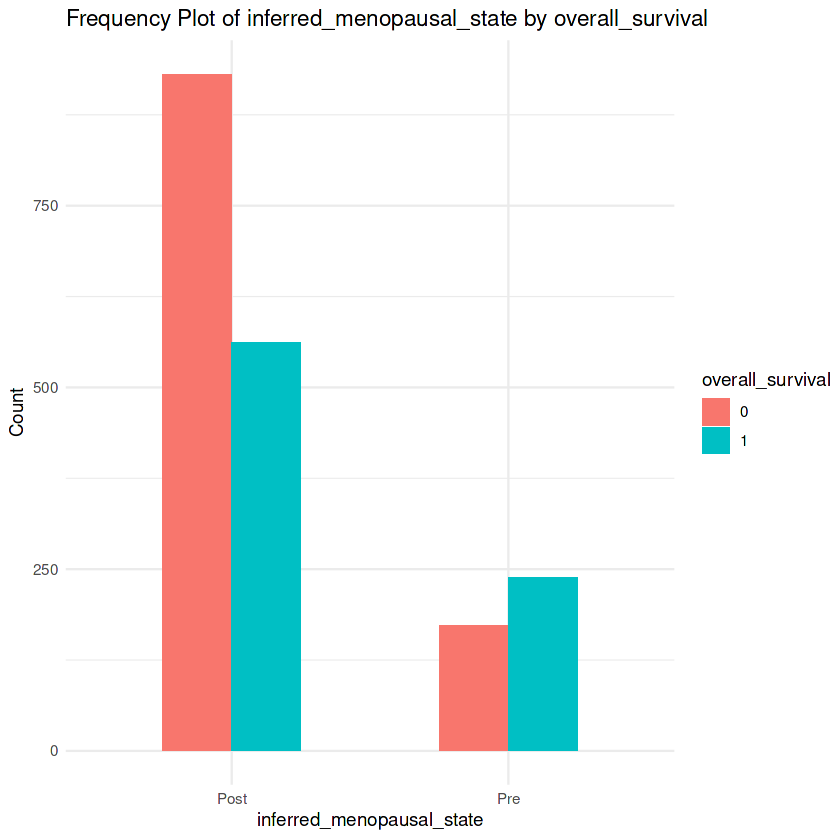

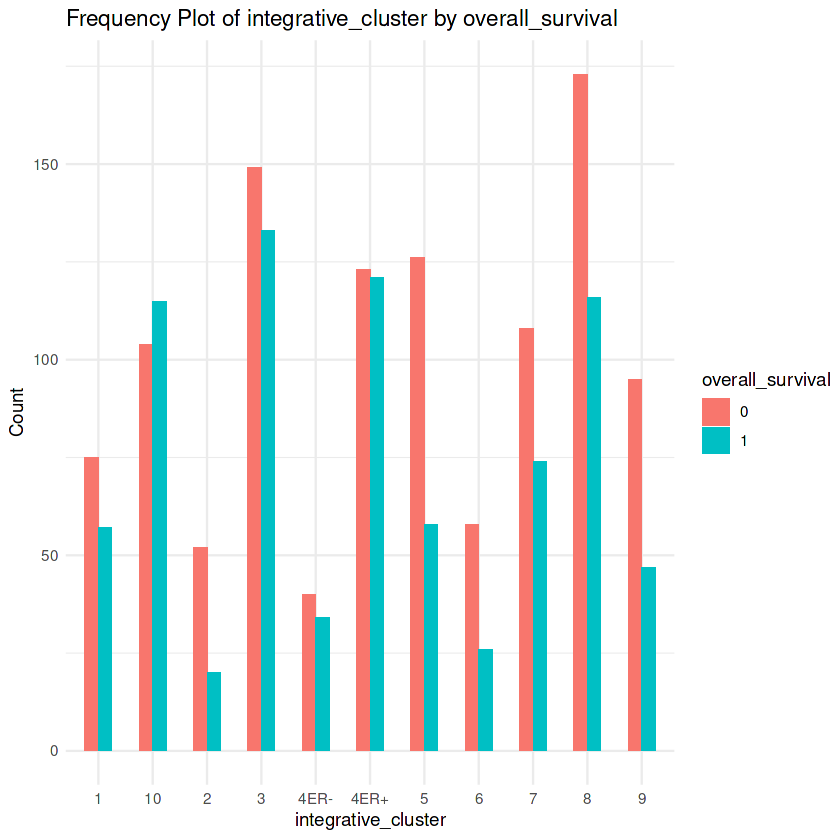

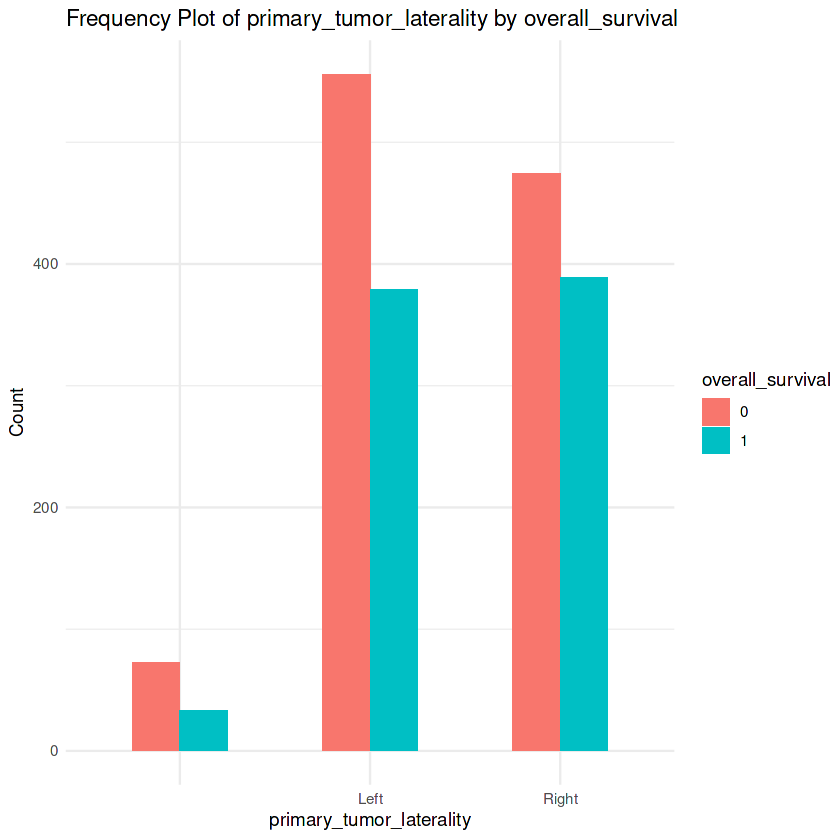

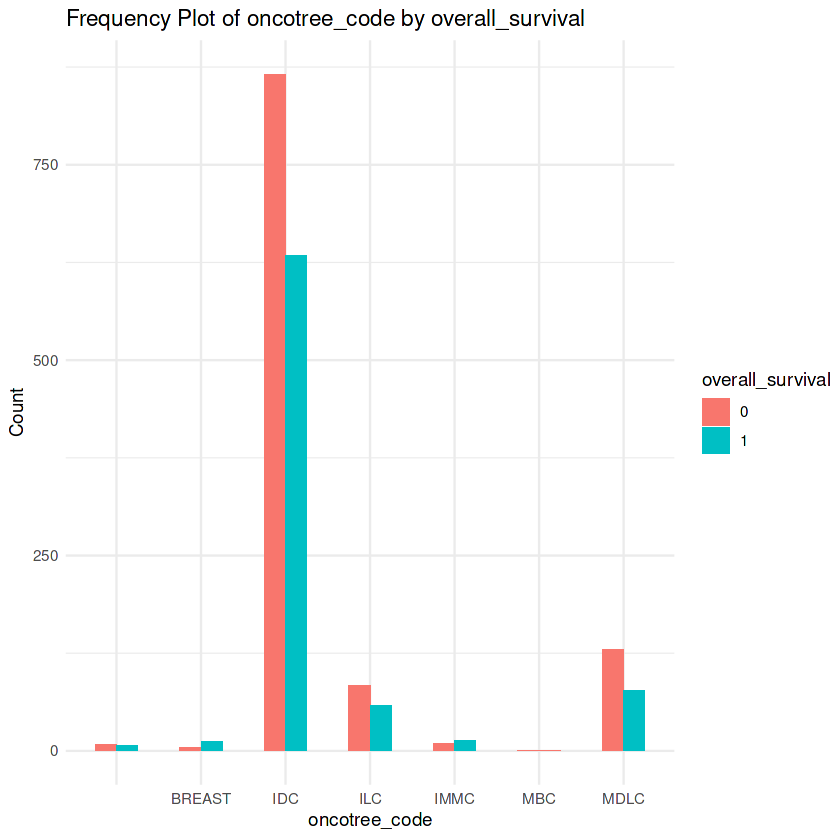

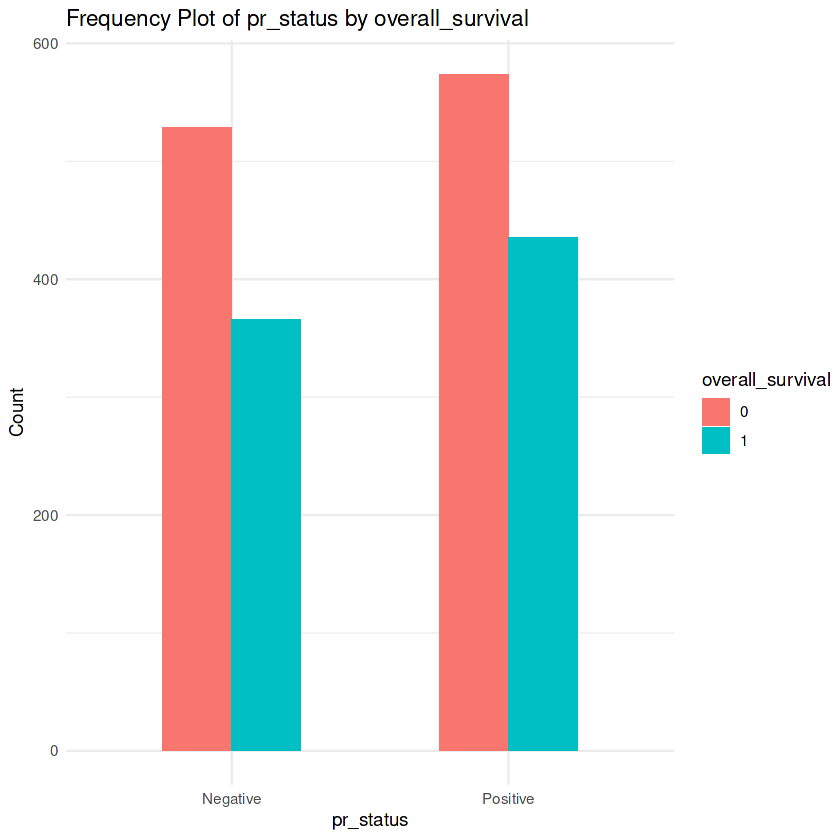

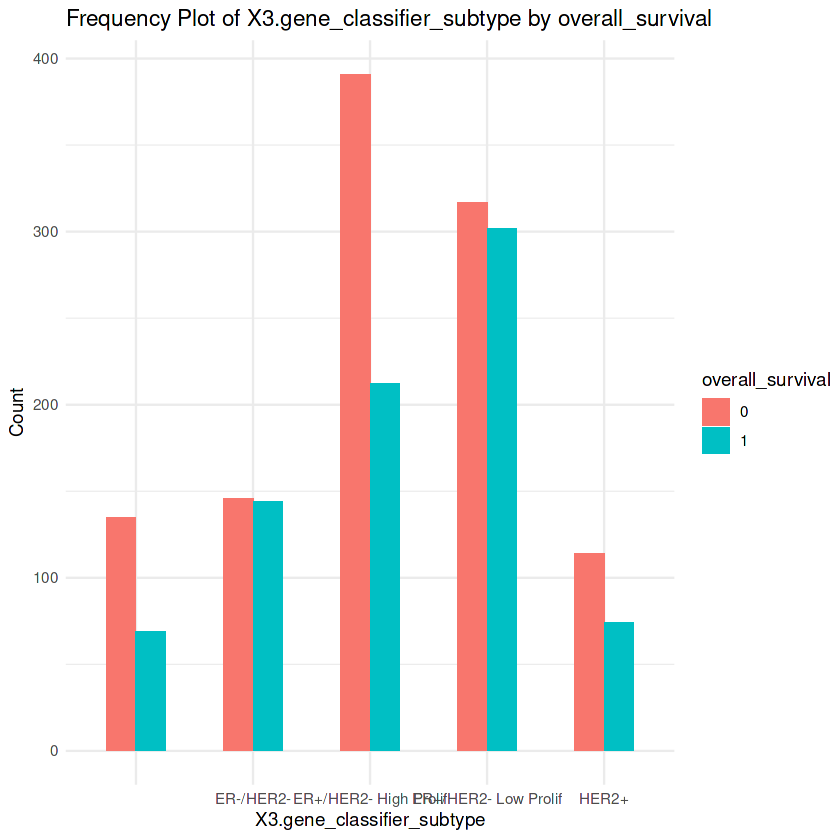

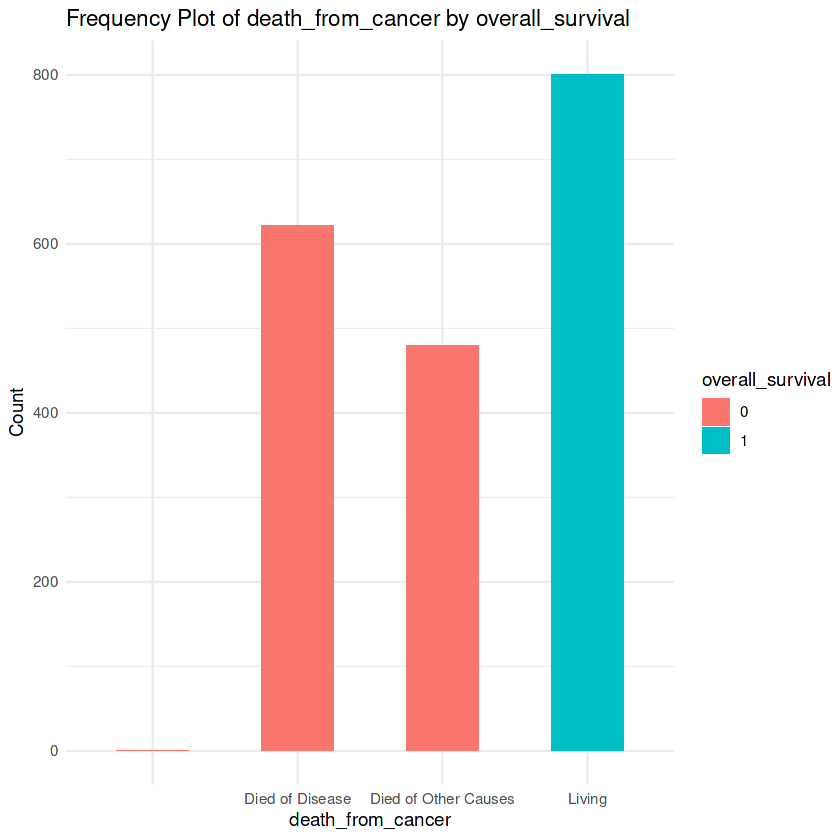

In [37]:
# Function to create frequency plots
create_frequency_plots <- function(data, group_var, attributes) {
  for (attr in attributes) {
    plot <- ggplot(data, aes_string(x = attr, fill = group_var)) +
      geom_bar(position = "dodge", width = 0.5) +
      labs(title = paste("Frequency Plot of", attr, "by", group_var),
           x = attr,
           y = "Count") +
      theme_minimal()
    
    print(plot)
  }
}



# Define the grouping variable and categorical attributes
group_var <- "overall_survival"
attributes <- categorical_clinical_attributes


# Create the plots
create_frequency_plots(METABRIC_Clinical, group_var, attributes)



## **1. Hierarchical clustering** <a class="anchor" id="2"></a>

In [26]:
# Perform hierarchical clustering using Ward's method.
d <- dist(t(METABRIC_RNA))
hc <- hclust(d, method = "ward.D2")

Determining the Optimal Number of Clusters : silhouette method

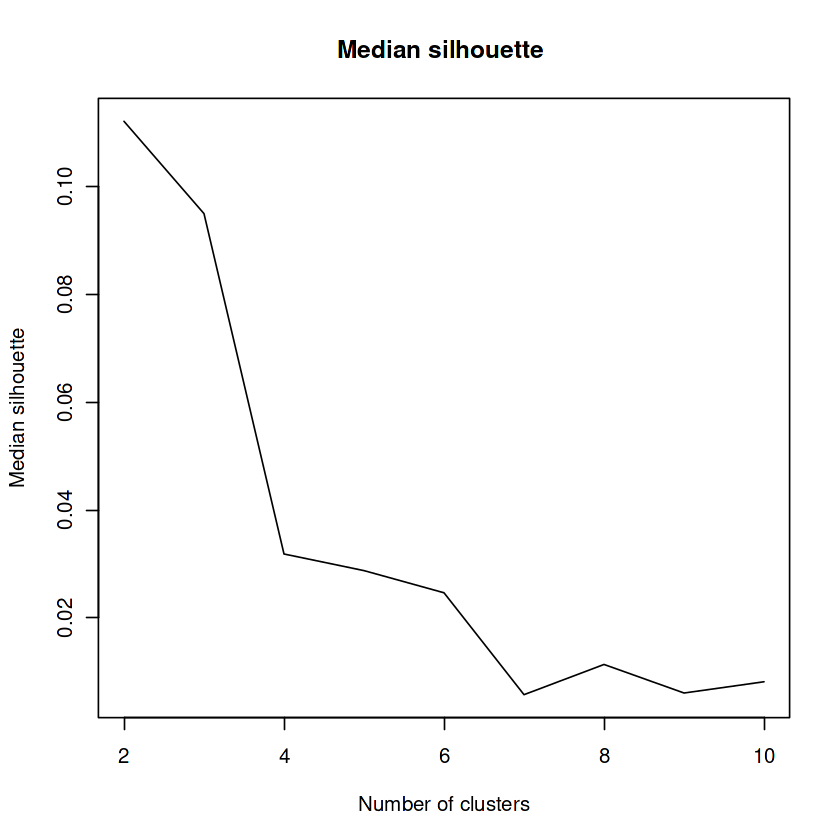

In [27]:
K <- 2:10
sh <- NULL
for (i in K) {
  sh <- c(sh, median(silhouette(cutree(hc, k = i), dist = d)[, 3], na.rm = T))
}

# Plot silhouette
plot(K, sh, type = "l", main = "Median silhouette ", xlab = "Number of clusters", ylab = "Median silhouette") 


# Obtain optimal clusters
cl <- cutree(hc, k = K[which.max(sh)])

Median silhouette value is highest for 2 clusters

In [28]:
# counts of each cluster
sum(cl==1)
sum(cl==2)

[1] 1417

[1] 487

Heatmap

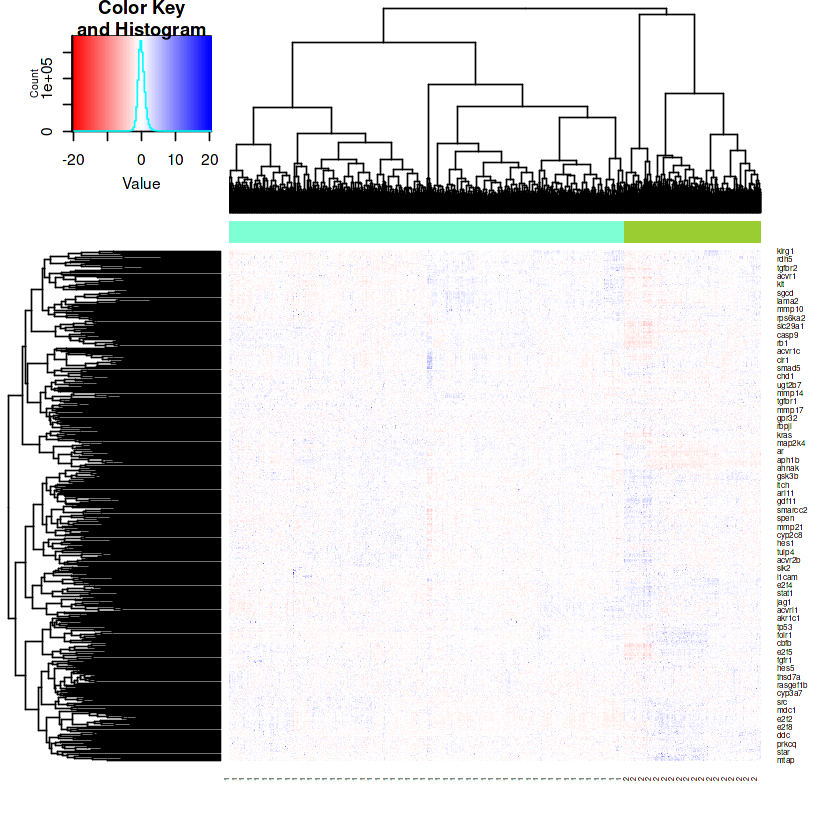

In [29]:
# Specify colour palette
cols <- colors()[seq(9, length(colors()), len = length(unique(cl)))]

# Produce heatmap
heatmap.2(METABRIC_RNA,  Colv = as.dendrogram(hc), margins = c(5, 5), labCol = cl,  trace = "none", ColSideColors = cols[cl], col = redblue(100))

Cut tree for 4 clusters

In [30]:
cl <- cutree(hc, k = 4)

# counts of each cluster
sum(cl==1)
sum(cl==2)
sum(cl==3)
sum(cl==4)

[1] 707

[1] 710

[1] 387

[1] 100

Heatmap

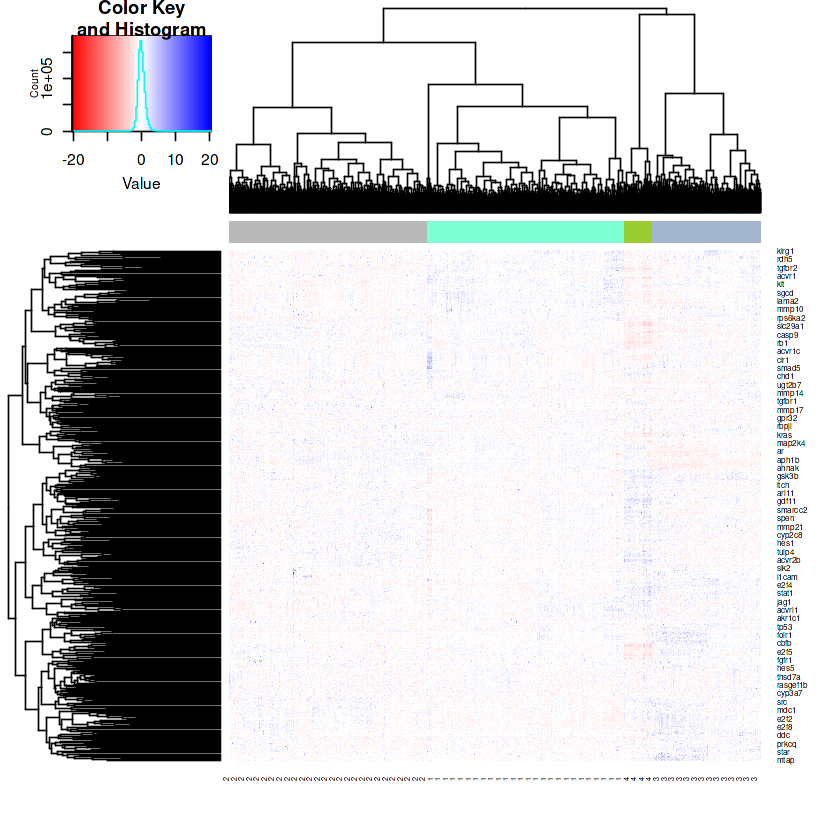

In [31]:
# Specify colour palette
cols <- colors()[seq(9, length(colors()), len = length(unique(cl)))]

# Produce heatmap
heatmap.2(METABRIC_RNA,  Colv = as.dendrogram(hc), margins = c(5, 5), labCol = cl,  trace = "none", ColSideColors = cols[cl], col = redblue(100))

## **2. Gene Expression Analysis** <a class="anchor" id="3"></a>

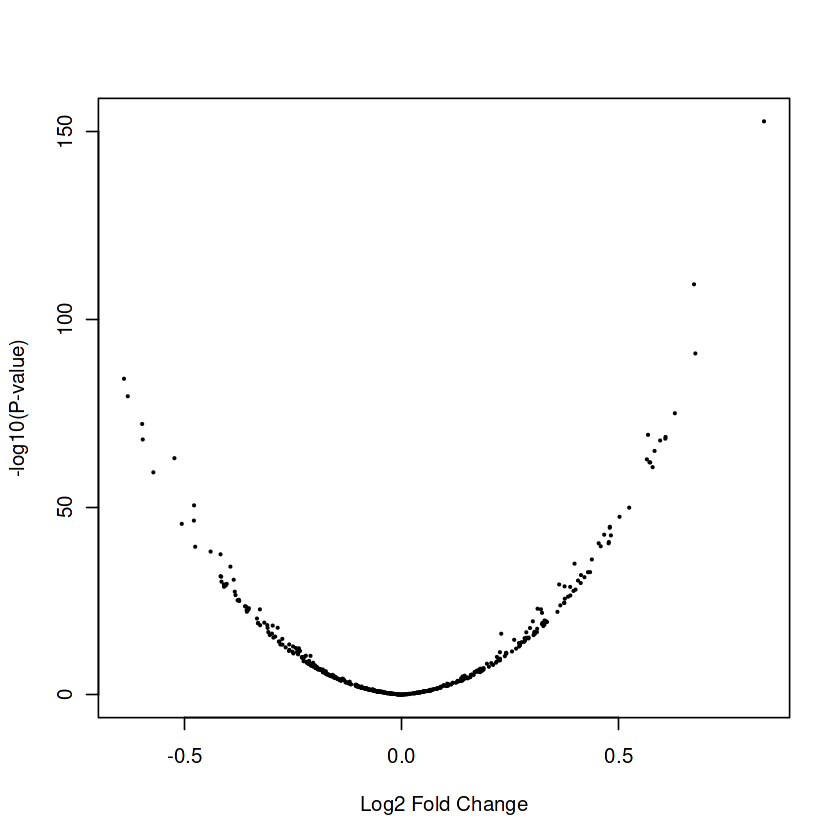

In [32]:
# Specify design matrix
design <-model.matrix(~as.factor(cl)) 

# Construct DE object
DE.object <-lmFit(METABRIC_RNA, design)

# Perform Empirical Bayes
DE.object <-eBayes(DE.object)

#Volcano plot
volcanoplot(DE.object)


In [33]:
DE.object

An object of class "MArrayLM"
$coefficients
      (Intercept) as.factor(cl)2 as.factor(cl)3 as.factor(cl)4
brca1 -0.37704710      0.7409284     0.26589671     0.88935310
brca2  0.02899222     -0.1170812     0.06754137     0.01787178
palb2 -0.17969364      0.4241457     0.21094428    -0.40641536
pten   0.38368317     -0.4314492    -0.95193485    -0.55806717
tp53  -0.02260806      0.0974851     0.08719075    -0.59910294
484 more rows ...

$rank
[1] 4

$assign
[1] 0 1 1 1

$qr
$qr
   (Intercept) as.factor(cl)2 as.factor(cl)3 as.factor(cl)4
1 -43.63484846   -16.27139832  -8.8690579587  -2.2917462426
2   0.02291746   -21.10074872   6.8391873999   1.7672318863
3   0.02291746    -0.01727639  16.1729813774  -2.0040869117
4   0.02291746    -0.01727639   0.0195843428   9.3599373005
5   0.02291746     0.03011530  -0.0004358697  -0.0002824038
1899 more rows ...

$qraux
[1] 1.022917 1.030115 1.019584 1.012689

$pivot
[1] 1 2 3 4

$tol
[1] 1e-07

$rank
[1] 4


$df.residual
[1] 1900 1900 1900 1900 19

#### **Differentially Expressed genes**

In [ ]:
#DE genes between cluster 1 and 2

pval2 <-DE.object$p.value[,2]
sprintf("There are %i differentially expressed genes between cluster 1 and 2 with p-values <= 0.05.", sum(pval2 <=0.05))

#DE genes between cluster 1 and 3

pval3 <-DE.object$p.value[,3]
sprintf("There are %i differentially expressed genes between cluster 1 and 2 with p-values <= 0.05.", sum(pval3 <=0.05))

#DE genes between cluster 1 and 4

pval4 <-DE.object$p.value[,4]
sprintf("There are %i differentially expressed genes between cluster 1 and 2 with p-values <= 0.05.", sum(pval4 <=0.05))


In [34]:
design

,(Intercept),as.factor(cl)2,as.factor(cl)3,as.factor(cl)4
1,1,0,0,0
2,1,1,0,0
3,1,0,0,0
4,1,0,0,0
5,1,1,0,0
6,1,0,0,0
7,1,0,0,0
8,1,0,0,0
9,1,1,0,0
10,1,1,0,0


In [35]:
#Extracting top 20 list of statistically significant DE genes
DE.top <-topTable(DE.object, number =20,  coef = NULL, adjust.method = "BH")

DE_genes <-rownames(DE.top)

DE_genes

Removing intercept from test coefficients



[1] "gata3"    "tgfbr2"   "lama2"    "ccne1"    "rheb"     "chek1"   
 [7] "mapt"     "hsd17b11" "cdk6"     "egfr"     "e2f2"     "map2k1"  
[13] "itgav"    "e2f3"     "jak1"     "kmt2c"    "map4"     "cbfb"    
[19] "tgfb3"    "cdc25a"

### **GO enrichment analysis**

In [ ]:
# Install BiocManager if not already installed
if (!requireNamespace("BiocManager", quietly = TRUE)) {
  install.packages("BiocManager")
}

# Load BiocManager
library(BiocManager)
# Install clusterProfiler and org.Hs.eg.db
BiocManager::install("clusterProfiler")
BiocManager::install("org.Hs.eg.db")  # Example annotation package for human genes

# Load required packages
library(clusterProfiler)
library(org.Hs.eg.db)

In [ ]:
# Convert gene symbols to Entrez gene IDs using org.Hs.eg.db
gene_ids <- bitr(DE_genes, fromType = "SYMBOL", toType = "ENTREZID", OrgDb = org.Hs.eg.db)

# Perform GO enrichment analysis
go_enrich <- enrichGO(gene = gene_ids$ENTREZID,
                      OrgDb = org.Hs.eg.db,
                      keyType = "ENTREZID",
                      ont = "BP",  # Biological Process ontology; other options: "MF" (Molecular Function), "CC" (Cellular Component)
                      pvalueCutoff = 0.05,
                      qvalueCutoff = 0.2,
                      readable = TRUE)

# View the results
summary(go_enrich)

In [ ]:
# Perform KEGG pathway enrichment analysis
kegg_enrich <- enrichKEGG(gene = gene_ids$ENTREZID,
                          organism = 'hsa',  # for Homo sapiens
                          pvalueCutoff = 0.05,
                          qvalueCutoff = 0.2)

# View the results
summary(kegg_enrich)

In [ ]:
# Plot GO enrichment results
dotplot(go_enrich, showCategory = 20)  # Show top 20 enriched categories

# Plot KEGG pathway enrichment results
dotplot(kegg_enrich, showCategory = 10)  # Show top 10 enriched pathways

## **3. Survival analysis** <a class="anchor" id="4"></a>

Create survival object for Kaplan-Meier Survival Curves

In [39]:
Y <- Surv(METABRIC_Clinical$overall_survival_months, METABRIC_Clinical$overall_survival == 0)

### Hazard ratio : between different clusters

In [40]:
# Perform Cox regression to estimate HR  between clusters
cox.model <- coxph(Surv(overall_survival_months,overall_survival== 0) ~  as.factor(cl), data = METABRIC_Clinical)

summary(cox.model)

Call:
coxph(formula = Surv(overall_survival_months, overall_survival == 
    0) ~ as.factor(cl), data = METABRIC_Clinical)

  n= 1904, number of events= 1103 

                  coef exp(coef) se(coef)     z Pr(>|z|)    
as.factor(cl)2 0.47840   1.61349  0.07114 6.725 1.76e-11 ***
as.factor(cl)3 0.35019   1.41933  0.08675 4.037 5.42e-05 ***
as.factor(cl)4 0.14269   1.15337  0.13065 1.092    0.275    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

               exp(coef) exp(-coef) lower .95 upper .95
as.factor(cl)2     1.613     0.6198    1.4035     1.855
as.factor(cl)3     1.419     0.7046    1.1974     1.682
as.factor(cl)4     1.153     0.8670    0.8928     1.490

Concordance= 0.562  (se = 0.008 )
Likelihood ratio test= 48.72  on 3 df,   p=1e-10
Wald test            = 47.6  on 3 df,   p=3e-10
Score (logrank) test = 48.35  on 3 df,   p=2e-10


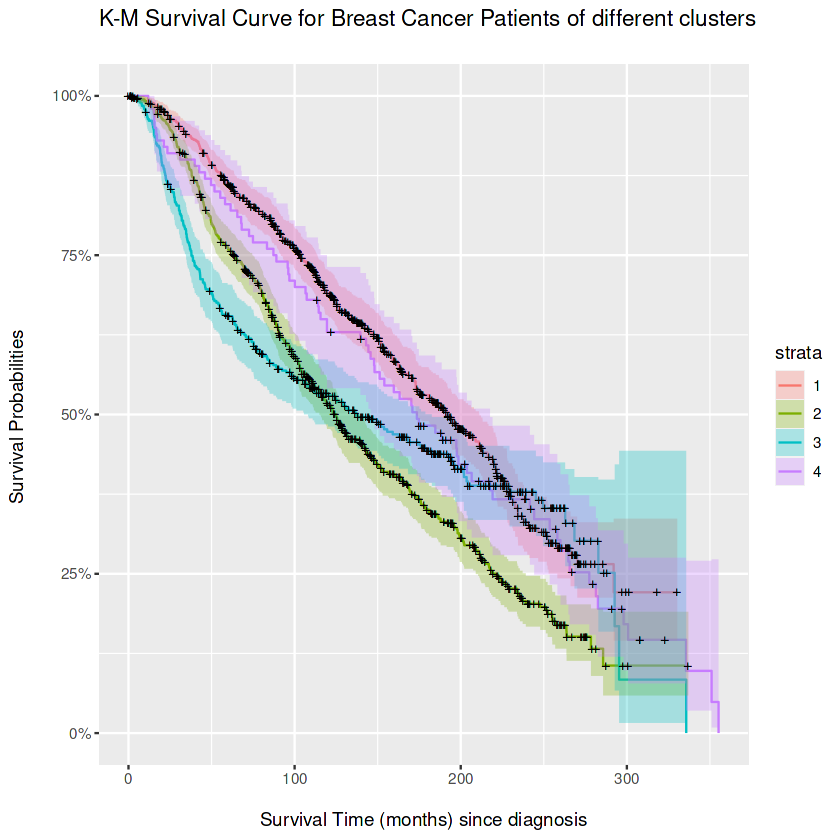

In [41]:
#Kaplan-Meier Survival Curve 
kmfit <- survfit(Y ~  cl)

p1 <- autoplot(kmfit) +
  labs(x = "\n Survival Time (months) since diagnosis ", 
       y = "Survival Probabilities \n", 
       title = "K-M Survival Curve for Breast Cancer Patients of different clusters \n")
  

p1

### Hazard ratio : integrative_cluster

In [42]:
# Perform Cox regression to estimate HR 
cox.model_integrative_cluster <- coxph(Surv(overall_survival_months, overall_survival== 0) ~  as.factor(integrative_cluster), data = METABRIC_Clinical) 

summary(cox.model_integrative_cluster)

Call:
coxph(formula = Surv(overall_survival_months, overall_survival == 
    0) ~ as.factor(integrative_cluster), data = METABRIC_Clinical)

  n= 1904, number of events= 1103 

                                      coef exp(coef) se(coef)      z Pr(>|z|)
as.factor(integrative_cluster)10   -0.2627    0.7689   0.1519 -1.730  0.08360
as.factor(integrative_cluster)2     0.1632    1.1773   0.1822  0.896  0.37021
as.factor(integrative_cluster)3    -0.2884    0.7495   0.1417 -2.036  0.04176
as.factor(integrative_cluster)4ER- -0.1093    0.8965   0.1960 -0.558  0.57704
as.factor(integrative_cluster)4ER+ -0.2329    0.7922   0.1466 -1.589  0.11210
as.factor(integrative_cluster)5     0.4797    1.6156   0.1459  3.287  0.00101
as.factor(integrative_cluster)6     0.1854    1.2037   0.1750  1.060  0.28922
as.factor(integrative_cluster)7    -0.1732    0.8410   0.1505 -1.151  0.24977
as.factor(integrative_cluster)8    -0.1517    0.8592   0.1384 -1.096  0.27298
as.factor(integrative_cluster)9     0.2019 

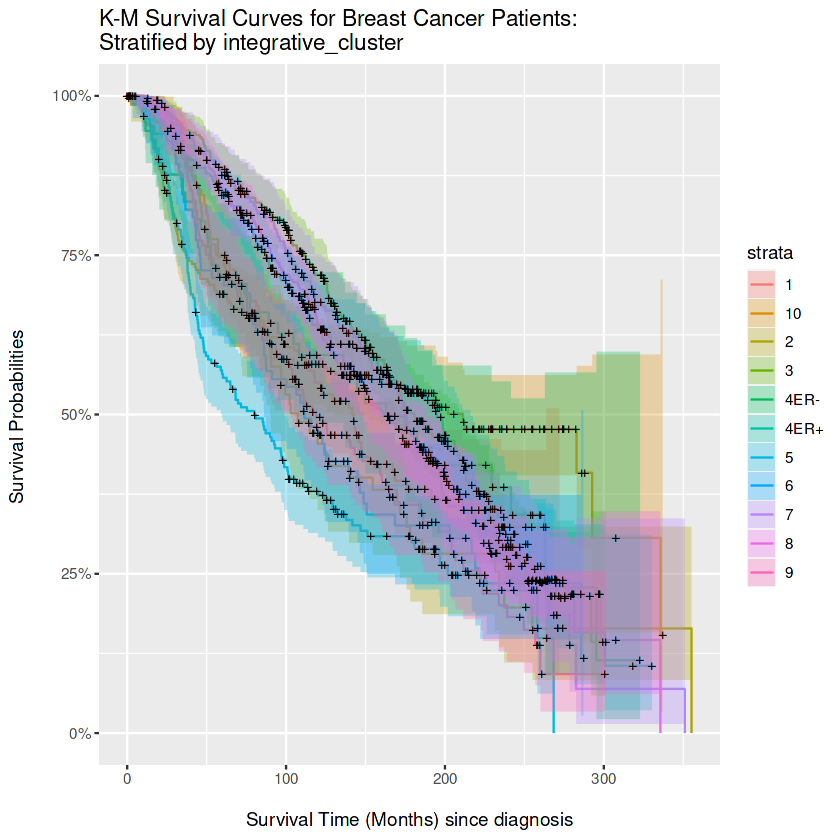

In [43]:
kmfit <- survfit(Y ~  METABRIC_Clinical$integrative_cluster  )
#Kaplan-Meier Survival Curve 
autoplot(kmfit) +
  labs(x = "\n Survival Time (Months) since diagnosis ", 
       y = "Survival Probabilities \n", 
       title = "K-M Survival Curves for Breast Cancer Patients: \nStratified by integrative_cluster")

### Hazard ratio : type_of_breast_surgery

In [44]:
# Perform Cox regression to estimate HR 
cox.model_type_of_breast_surgery <- coxph(Surv(overall_survival_months, overall_survival== 0) ~  as.factor(type_of_breast_surgery), data = METABRIC_Clinical) 

summary(cox.model_type_of_breast_surgery)

Call:
coxph(formula = Surv(overall_survival_months, overall_survival == 
    0) ~ as.factor(type_of_breast_surgery), data = METABRIC_Clinical)

  n= 1904, number of events= 1103 

                                                      coef exp(coef) se(coef)
as.factor(type_of_breast_surgery)BREAST CONSERVING -0.8979    0.4074   0.2894
as.factor(type_of_breast_surgery)MASTECTOMY        -0.4317    0.6494   0.2864
                                                        z Pr(>|z|)   
as.factor(type_of_breast_surgery)BREAST CONSERVING -3.103  0.00192 **
as.factor(type_of_breast_surgery)MASTECTOMY        -1.507  0.13172   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

                                                   exp(coef) exp(-coef)
as.factor(type_of_breast_surgery)BREAST CONSERVING    0.4074      2.454
as.factor(type_of_breast_surgery)MASTECTOMY           0.6494      1.540
                                                   lower .95 upper .95
as.factor(type_of_bre

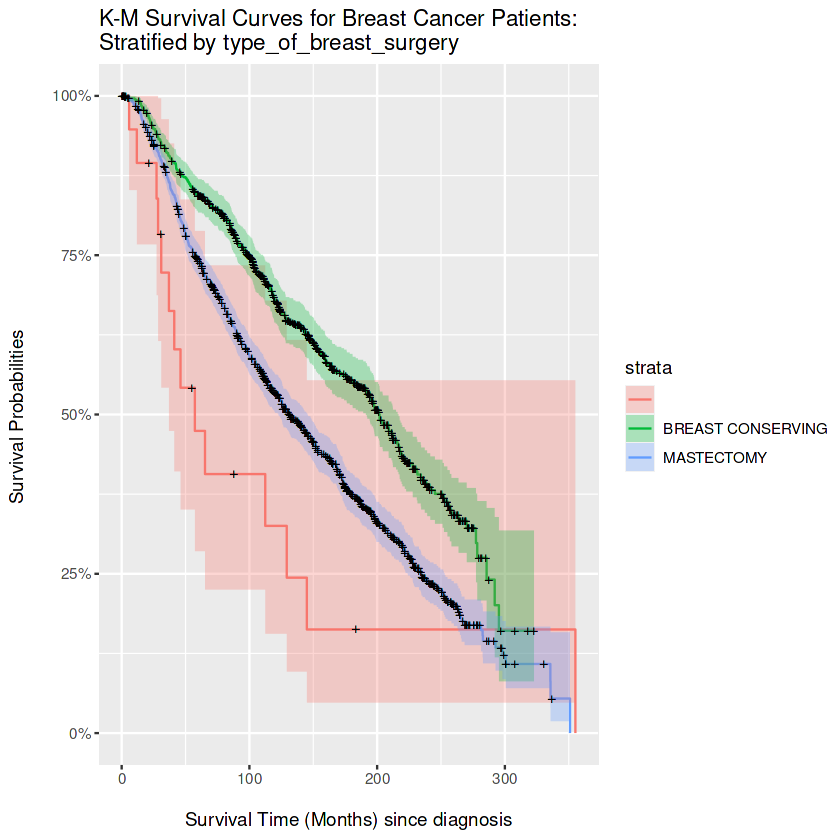

In [45]:
kmfit <- survfit(Y ~  METABRIC_Clinical$type_of_breast_surgery  )
#Kaplan-Meier Survival Curve 
autoplot(kmfit) +
  labs(x = "\n Survival Time (Months) since diagnosis ", 
       y = "Survival Probabilities \n", 
       title = "K-M Survival Curves for Breast Cancer Patients: \nStratified by type_of_breast_surgery")

### Hazard ratio : cellularity

In [46]:
# Perform Cox regression to estimate HR 
cox.model_cellularity <- coxph(Surv(overall_survival_months, overall_survival== 0) ~  as.factor(cellularity), data = METABRIC_Clinical) 

summary(cox.model_cellularity)

Call:
coxph(formula = Surv(overall_survival_months, overall_survival == 
    0) ~ as.factor(cellularity), data = METABRIC_Clinical)

  n= 1904, number of events= 1103 

                                 coef exp(coef) se(coef)     z Pr(>|z|)
as.factor(cellularity)High     0.2825    1.3264   0.2008 1.407    0.160
as.factor(cellularity)Low      0.2278    1.2558   0.2185 1.042    0.297
as.factor(cellularity)Moderate 0.2727    1.3136   0.2021 1.349    0.177

                               exp(coef) exp(-coef) lower .95 upper .95
as.factor(cellularity)High         1.326     0.7539    0.8948     1.966
as.factor(cellularity)Low          1.256     0.7963    0.8184     1.927
as.factor(cellularity)Moderate     1.314     0.7613    0.8839     1.952

Concordance= 0.514  (se = 0.009 )
Likelihood ratio test= 2.34  on 3 df,   p=0.5
Wald test            = 2.16  on 3 df,   p=0.5
Score (logrank) test = 2.17  on 3 df,   p=0.5


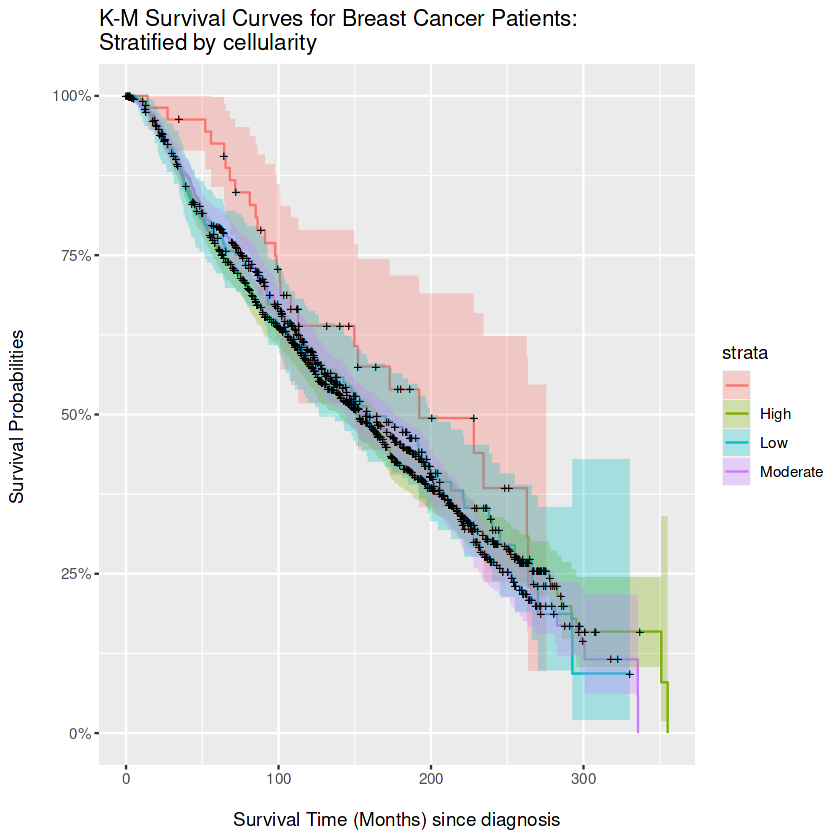

In [47]:
kmfit <- survfit(Y ~  METABRIC_Clinical$cellularity  )
#Kaplan-Meier Survival Curve 
autoplot(kmfit) +
  labs(x = "\n Survival Time (Months) since diagnosis ", 
       y = "Survival Probabilities \n", 
       title = "K-M Survival Curves for Breast Cancer Patients: \nStratified by cellularity")

### Hazard ratio : chemotherapy

In [48]:
# Perform Cox regression to estimate HR 
cox.model_chemotherapy <- coxph(Surv(overall_survival_months, overall_survival== 0) ~  as.factor(chemotherapy), data = METABRIC_Clinical) 

summary(cox.model_chemotherapy)

Call:
coxph(formula = Surv(overall_survival_months, overall_survival == 
    0) ~ as.factor(chemotherapy), data = METABRIC_Clinical)

  n= 1904, number of events= 1103 

                            coef exp(coef) se(coef)    z Pr(>|z|)   
as.factor(chemotherapy)1 0.20539   1.22800  0.07665 2.68  0.00737 **
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

                         exp(coef) exp(-coef) lower .95 upper .95
as.factor(chemotherapy)1     1.228     0.8143     1.057     1.427

Concordance= 0.536  (se = 0.007 )
Likelihood ratio test= 6.88  on 1 df,   p=0.009
Wald test            = 7.18  on 1 df,   p=0.007
Score (logrank) test = 7.21  on 1 df,   p=0.007


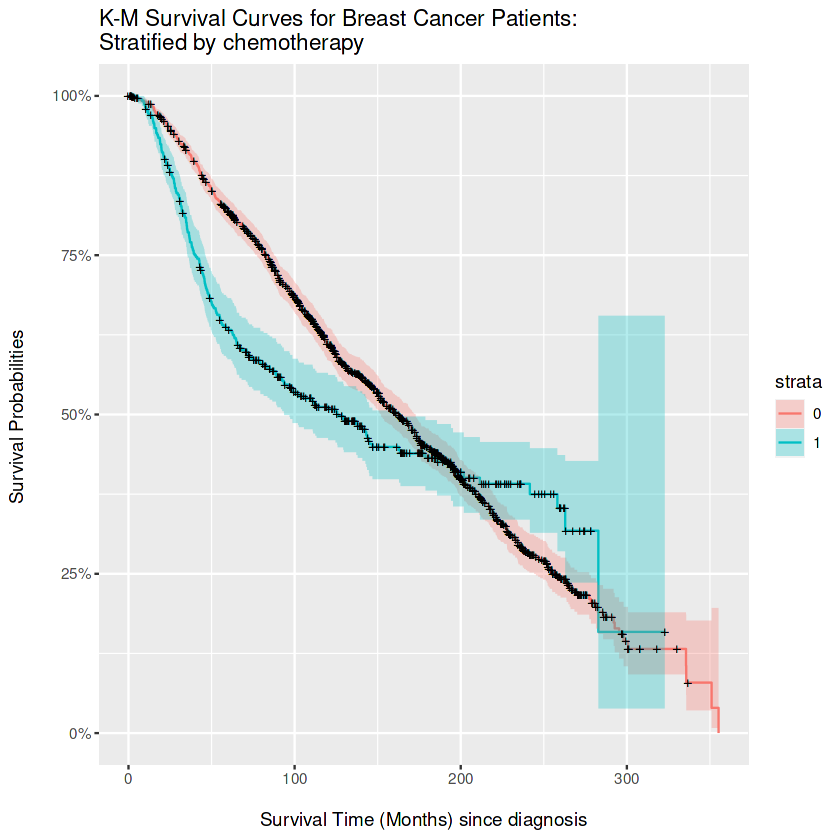

In [49]:
kmfit <- survfit(Y ~  METABRIC_Clinical$chemotherapy  )
#Kaplan-Meier Survival Curve 
autoplot(kmfit) +
  labs(x = "\n Survival Time (Months) since diagnosis ", 
       y = "Survival Probabilities \n", 
       title = "K-M Survival Curves for Breast Cancer Patients: \nStratified by chemotherapy")

### Hazard ratio : tumor_stage

In [50]:
# Perform Cox regression to estimate HR 
cox.model_tumor_stage <- coxph(Surv(overall_survival_months, overall_survival== 0) ~  as.factor(tumor_stage), data = METABRIC_Clinical) 

summary(cox.model_tumor_stage)

Call:
coxph(formula = Surv(overall_survival_months, overall_survival == 
    0) ~ as.factor(tumor_stage), data = METABRIC_Clinical)

  n= 1403, number of events= 792 
   (501 observations deleted due to missingness)

                           coef exp(coef) se(coef)     z Pr(>|z|)  
as.factor(tumor_stage)1 0.04608   1.04716  1.00250 0.046    0.963  
as.factor(tumor_stage)2 0.63057   1.87867  1.00118 0.630    0.529  
as.factor(tumor_stage)3 1.25186   3.49684  1.00599 1.244    0.213  
as.factor(tumor_stage)4 1.83352   6.25587  1.06111 1.728    0.084 .
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

                        exp(coef) exp(-coef) lower .95 upper .95
as.factor(tumor_stage)1     1.047     0.9550    0.1468      7.47
as.factor(tumor_stage)2     1.879     0.5323    0.2640     13.37
as.factor(tumor_stage)3     3.497     0.2860    0.4868     25.12
as.factor(tumor_stage)4     6.256     0.1598    0.7818     50.06

Concordance= 0.61  (se = 0.009 )
Likelihood ratio

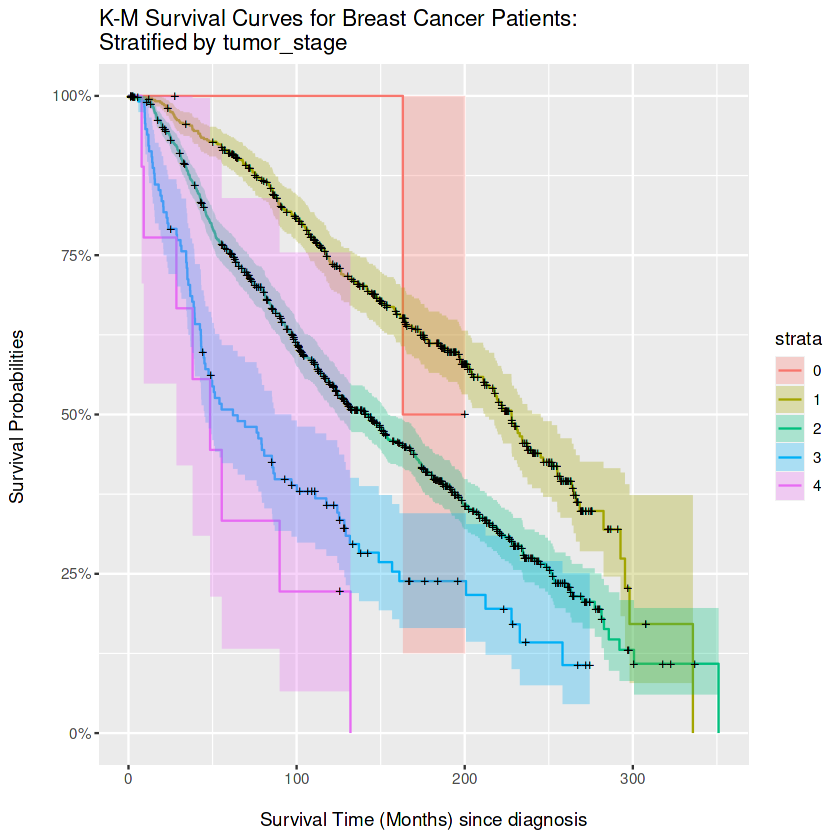

In [51]:
kmfit <- survfit(Y ~  METABRIC_Clinical$tumor_stage  )
#Kaplan-Meier Survival Curve 
autoplot(kmfit) +
  labs(x = "\n Survival Time (Months) since diagnosis ", 
       y = "Survival Probabilities \n", 
       title = "K-M Survival Curves for Breast Cancer Patients: \nStratified by tumor_stage")

#### tumor stage 0 masks the significance of hazard ratios

In [54]:
# Remove observations where tumor stage == 0
METABRIC_Clinical_filtered <- METABRIC_Clinical %>%
  filter(tumor_stage != 0)

In [55]:
# Perform Cox regression to estimate HR 
cox.model_tumor_stage <- coxph(Surv(overall_survival_months, overall_survival== 0) ~  as.factor(tumor_stage), data = METABRIC_Clinical_filtered) 

summary(cox.model_tumor_stage)

Call:
coxph(formula = Surv(overall_survival_months, overall_survival == 
    0) ~ as.factor(tumor_stage), data = METABRIC_Clinical_filtered)

  n= 1399, number of events= 791 

                           coef exp(coef) se(coef)     z Pr(>|z|)    
as.factor(tumor_stage)2 0.58423   1.79360  0.08235 7.094 1.30e-12 ***
as.factor(tumor_stage)3 1.20516   3.33731  0.12841 9.385  < 2e-16 ***
as.factor(tumor_stage)4 1.78593   5.96510  0.36139 4.942 7.74e-07 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

                        exp(coef) exp(-coef) lower .95 upper .95
as.factor(tumor_stage)2     1.794     0.5575     1.526     2.108
as.factor(tumor_stage)3     3.337     0.2996     2.595     4.292
as.factor(tumor_stage)4     5.965     0.1676     2.938    12.112

Concordance= 0.609  (se = 0.009 )
Likelihood ratio test= 105.7  on 3 df,   p=<2e-16
Wald test            = 111.1  on 3 df,   p=<2e-16
Score (logrank) test = 119.7  on 3 df,   p=<2e-16


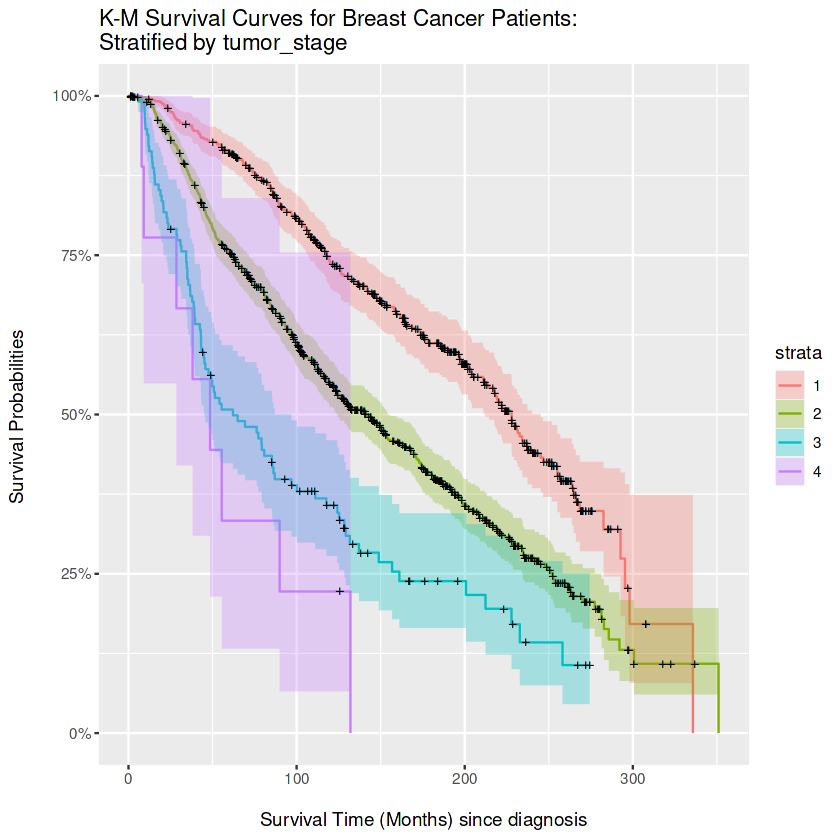

In [56]:
# survival object without tumor stage== 0
Y_filtered <- Surv(METABRIC_Clinical_filtered$overall_survival_months, METABRIC_Clinical_filtered$overall_survival == 0)

kmfit <- survfit(Y_filtered ~  METABRIC_Clinical_filtered$tumor_stage  )

#Kaplan-Meier Survival Curve 
autoplot(kmfit) +
  labs(x = "\n Survival Time (Months) since diagnosis ", 
       y = "Survival Probabilities \n", 
       title = "K-M Survival Curves for Breast Cancer Patients: \nStratified by tumor_stage")

### Hazard ratio : Tumor size 

Warning message:
“Removed 20 rows containing non-finite values (`stat_boxplot()`).”


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
   1.00   17.00   23.00   26.24   30.00  182.00      20 

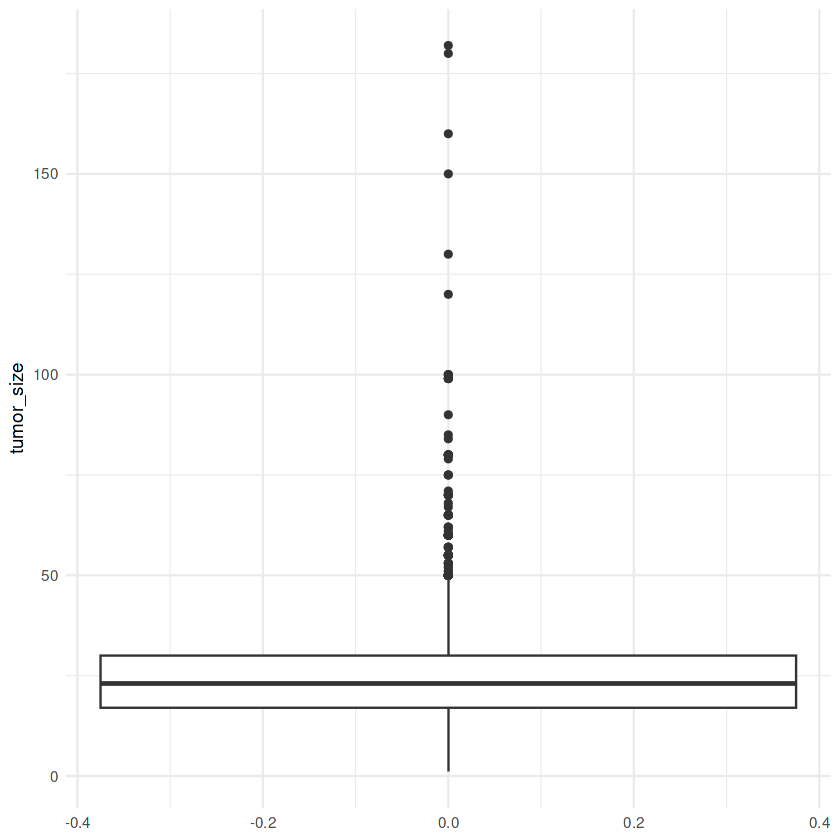

In [57]:
ggplot(METABRIC_Clinical, aes(y = tumor_size)) +
  geom_boxplot()+
  theme_minimal() 
  

summary(METABRIC_Clinical$tumor_size)

In [58]:
# Perform Cox regression to estimate HR 
cox.model_tumor_size <- coxph(Surv(overall_survival_months, overall_survival== 0) ~  as.factor(tumor_size> 23), data = METABRIC_Clinical) 

summary(cox.model_tumor_size)

Call:
coxph(formula = Surv(overall_survival_months, overall_survival == 
    0) ~ as.factor(tumor_size > 23), data = METABRIC_Clinical)

  n= 1884, number of events= 1090 
   (20 observations deleted due to missingness)

                                  coef exp(coef) se(coef)     z Pr(>|z|)    
as.factor(tumor_size > 23)TRUE 0.61988   1.85871  0.06126 10.12   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

                               exp(coef) exp(-coef) lower .95 upper .95
as.factor(tumor_size > 23)TRUE     1.859      0.538     1.648     2.096

Concordance= 0.59  (se = 0.008 )
Likelihood ratio test= 103.1  on 1 df,   p=<2e-16
Wald test            = 102.4  on 1 df,   p=<2e-16
Score (logrank) test = 105.6  on 1 df,   p=<2e-16


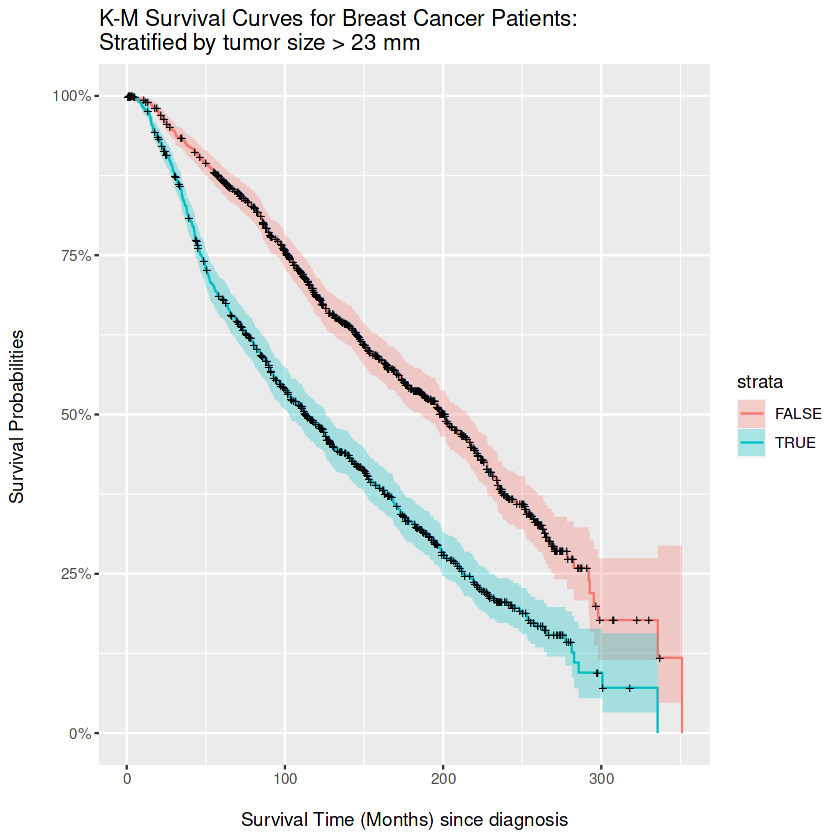

In [59]:
kmfit <- survfit(Y ~  METABRIC_Clinical$tumor_size> 23  )
#Kaplan-Meier Survival Curve 
autoplot(kmfit) +
  labs(x = "\n Survival Time (Months) since diagnosis ", 
       y = "Survival Probabilities \n", 
       title = "K-M Survival Curves for Breast Cancer Patients: \nStratified by tumor size > 23 mm")

### Hazard ratio : Age at diagnosis

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  21.93   51.38   61.77   61.09   70.59   96.29 

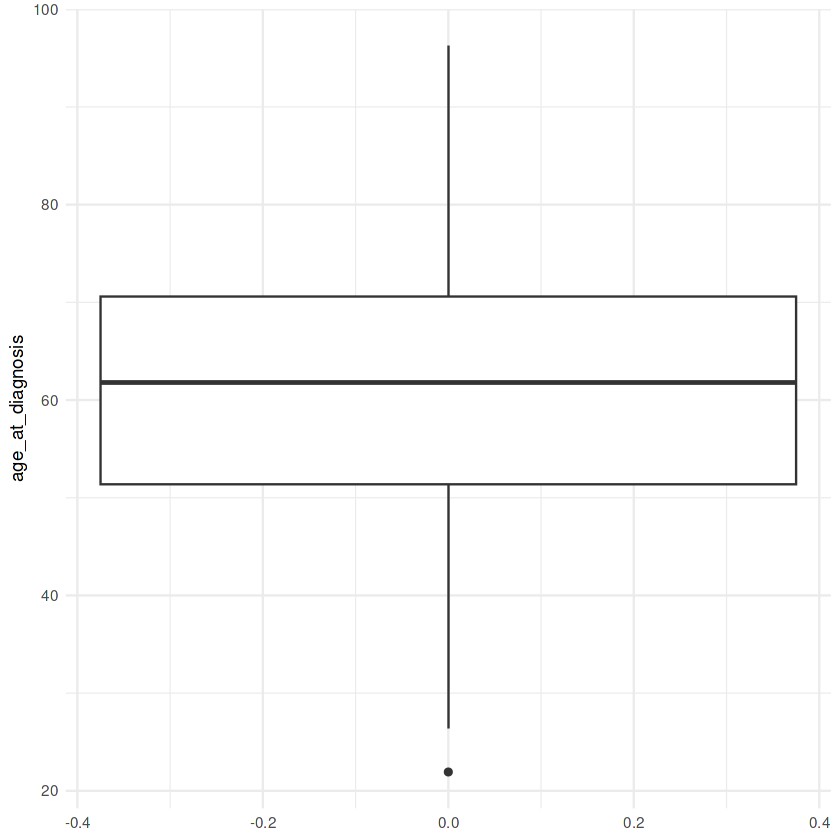

In [60]:
ggplot(METABRIC_Clinical) +
  geom_boxplot(aes(y = age_at_diagnosis))+
  theme_minimal()
  
summary(METABRIC_Clinical$age_at_diagnosis)



In [61]:
# Perform Cox regression to estimate HR 
cox.model_age_at_diagnosis <- coxph(Surv(overall_survival_months, overall_survival== 0) ~  as.factor(age_at_diagnosis> 61), data = METABRIC_Clinical) 

summary(cox.model_age_at_diagnosis)

Call:
coxph(formula = Surv(overall_survival_months, overall_survival == 
    0) ~ as.factor(age_at_diagnosis > 61), data = METABRIC_Clinical)

  n= 1904, number of events= 1103 

                                        coef exp(coef) se(coef)     z Pr(>|z|)
as.factor(age_at_diagnosis > 61)TRUE 0.68010   1.97408  0.06333 10.74   <2e-16
                                        
as.factor(age_at_diagnosis > 61)TRUE ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

                                     exp(coef) exp(-coef) lower .95 upper .95
as.factor(age_at_diagnosis > 61)TRUE     1.974     0.5066     1.744     2.235

Concordance= 0.558  (se = 0.008 )
Likelihood ratio test= 120.8  on 1 df,   p=<2e-16
Wald test            = 115.3  on 1 df,   p=<2e-16
Score (logrank) test = 119.7  on 1 df,   p=<2e-16


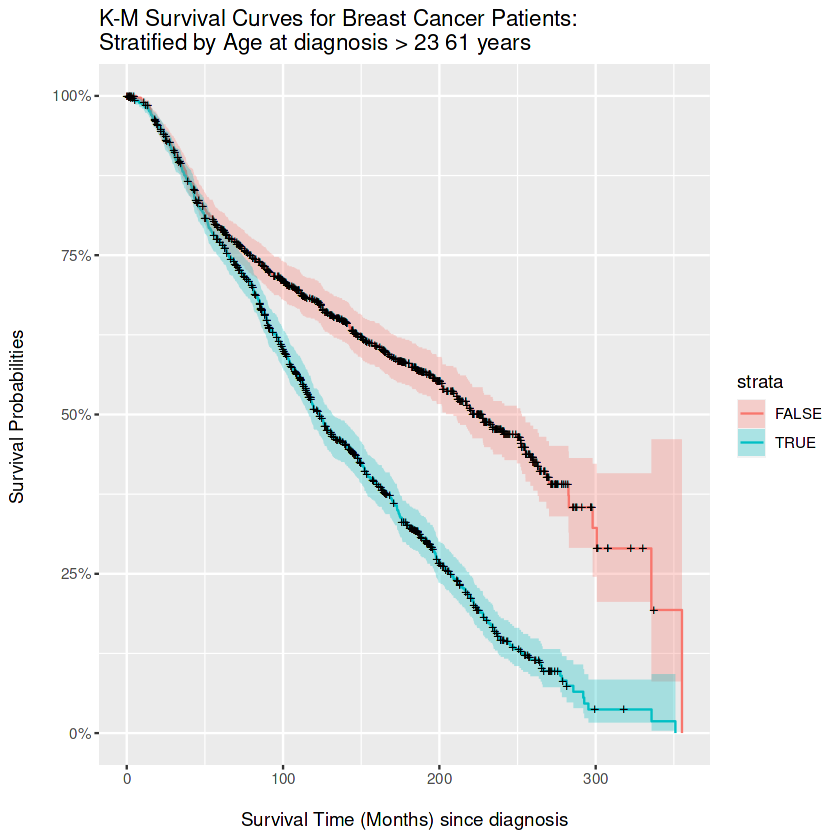

In [62]:
kmfit <- survfit(Y ~  METABRIC_Clinical$age_at_diagnosis> 61  )
#Kaplan-Meier Survival Curve 
autoplot(kmfit) +
  labs(x = "\n Survival Time (Months) since diagnosis ", 
       y = "Survival Probabilities \n", 
       title = "K-M Survival Curves for Breast Cancer Patients: \nStratified by Age at diagnosis > 23 61 years")

## **Result and Conclusion:** <a class="anchor" id="5"></a>


## **References:** <a class="anchor" id="6"></a>

* Asleh, K., Riaz, N., & Nielsen, T. O. (2022). Heterogeneity of triple negative breast cancer: Current advances in subtyping and treatment implications. Journal of Experimental & Clinical Cancer Research, 41(1), 265. https://doi.org/10.1186/s13046-022-02476-1

* Clarke, C., Madden, S. F., Doolan, P., Aherne, S. T., Joyce, H., O’Driscoll, L., Gallagher, W. M., Hennessy, B. T., Moriarty, M., Crown, J., Kennedy, S., & Clynes, M. (2013). Correlating transcriptional networks to breast cancer survival: A large-scale coexpression analysis. Carcinogenesis, 34(10), 2300–2308. https://doi.org/10.1093/carcin/bgt208

* Curtis, C., Shah, S. P., Chin, S.-F., Turashvili, G., Rueda, O. M., Dunning, M. J., Speed, D., Lynch, A. G., Samarajiwa, S., Yuan, Y., Gräf, S., Ha, G., Haffari, G., Bashashati, A., Russell, R., McKinney, S., Langerød, A., Green, A., Provenzano, E., ... Aparicio, S. (2012). The genomic and transcriptomic architecture of 2,000 breast tumours reveals novel subgroups. Nature, 486(7403), 346–352. https://doi.org/10.1038/nature10983

* Kao, K.-J., Chang, K.-M., Hsu, H.-C., & Huang, A. T. (2011). Correlation of microarray-based breast cancer molecular subtypes and clinical outcomes: Implications for treatment optimization. BMC Cancer, 11(1), 143. https://doi.org/10.1186/1471-2407-11-143

* Van ’T Veer, L. J., Dai, H., Van De Vijver, M. J., He, Y. D., Hart, A. A. M., Mao, M., Peterse, H. L., Van Der Kooy, K., Marton, M. J., Witteveen, A. T., Schreiber, G. J., Kerkhoven, R. M., Roberts, C., Linsley, P. S., Bernards, R., & Friend, S. H. (2002).Gene expression profiling predicts clinical outcome of breast cancer. Nature, 415(6871), 530–536. https://doi.org/10.1038/415530a
